# EEG Eye State — versione rigorosa migliorata

Questo notebook prende la **struttura metodologica forte di `EEG_Eye_Predict.ipynb`** e incorpora **solo gli elementi davvero utili** di `DataMining_Esame_(1).ipynb`.

## Obiettivi
1. Caricare il dataset in modo robusto.
2. Fare un'EDA chiara e leggibile.
3. Allenare e confrontare più modelli con **pipeline corrette** e **cross-validation**.
4. Valutare il modello migliore su un **test set stratificato**.
5. Aggiungere un **controllo cronologico di robustezza** per verificare il possibile effetto della dipendenza temporale.
6. Salvare modello e metriche finali.

## Scelte metodologiche chiave
- **Manteniamo l'unità di analisi originale** del dataset (una riga = una osservazione), come nel notebook migliore.
- **Tutto il preprocessing che apprende dai dati** resta **dentro una pipeline sklearn**, così evitiamo leakage.
- **Non** applichiamo, nella pipeline principale, windowing sovrapposto / feature engineering globale / selezione feature globale prima dello split: sono idee interessanti, ma qui aumentano il rischio di leakage o di complicazione inutile.
- Del secondo notebook teniamo soprattutto:
  - EDA più ricca;
  - distribuzioni per canale anche in scala log;
  - confronto tra classi per canale;
  - attenzione esplicita alla dipendenza temporale.

## 1) Setup e riproducibilità

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import math
import os
import random
import sys
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

import sklearn
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.10.18
NumPy: 1.26.4
Pandas: 2.3.0
scikit-learn: 1.6.1


## 2) Caricamento dati

In [2]:
# Strategia:
# 1) prova alcuni percorsi locali comuni per il CSV
# 2) se non trova nulla, prova a scaricare dal repository UCI via ucimlrepo

LOCAL_CANDIDATES = [
    Path("/content/eeg_eye_state.csv"),
    Path("/content/EEG Eye State.csv"),
    Path("eeg_eye_state.csv"),
    Path("EEG Eye State.csv"),
    Path("data/eeg_eye_state.csv"),
]

def load_from_local_csv():
    for path in LOCAL_CANDIDATES:
        if path.exists():
            df_local = pd.read_csv(path)
            print(f"Dataset caricato da file locale: {path}")
            return df_local
    return None

df = load_from_local_csv()

if df is None:
    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        print("Installo ucimlrepo...")
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"])
        from ucimlrepo import fetch_ucirepo

    eeg_eye_state = fetch_ucirepo(id=264)
    X_uci = eeg_eye_state.data.features.copy()
    y_uci = eeg_eye_state.data.targets.copy()

    # y può arrivare come DataFrame a una colonna
    if isinstance(y_uci, pd.DataFrame):
        y_series = y_uci.iloc[:, 0]
    else:
        y_series = pd.Series(y_uci, name="eyeDetection")

    df = X_uci.copy()
    df["eyeDetection"] = y_series.values
    print("Dataset caricato da UCI (id=264).")

# Standardizzazione nomi/target
df = df.copy()
df.columns = [str(c).strip() for c in df.columns]

possible_targets = ["eyeDetection", "eye_state", "EyeDetection", "target", "class"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Colonna target non trovata. Colonne disponibili: {list(df.columns)}")

if target_col != "eyeDetection":
    df = df.rename(columns={target_col: "eyeDetection"})

feature_cols = [c for c in df.columns if c != "eyeDetection"]
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["eyeDetection"] = pd.to_numeric(df["eyeDetection"], errors="coerce").astype("Int64")

print("\nShape:", df.shape)
print("Colonne:", list(df.columns))
df.head()

Dataset caricato da file locale: eeg_eye_state.csv

Shape: (11853, 15)
Colonne: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4316.41,4013.85,4267.69,4124.62,4342.56,4589.74,4089.23,4616.41,4200.51,4232.82,4213.33,4281.03,4630.26,4375.90,0
1,4305.13,4008.72,4259.49,4120.00,4341.03,4595.90,4092.82,4612.31,4199.49,4219.49,4198.46,4261.03,4611.79,4357.95,0
2,4293.33,3994.87,4254.36,4116.41,4337.44,4596.41,4092.31,4609.74,4193.33,4211.79,4186.67,4252.82,4597.95,4347.69,0
3,4297.44,3994.36,4258.46,4118.97,4336.92,4594.36,4096.92,4614.36,4193.33,4209.74,4192.31,4260.51,4602.05,4350.77,0
4,4308.21,4007.18,4268.21,4126.15,4344.62,4595.38,4102.05,4622.56,4205.13,4221.54,4205.13,4271.79,4614.36,4374.87,0


## 3) Controlli iniziali di qualità

In [3]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
    "n_unique": df.nunique(dropna=False),
})

print("Prime righe del riepilogo qualità:")
display(quality_summary)

duplicates = df.duplicated().sum()
target_dist = df["eyeDetection"].value_counts(dropna=False).sort_index()

print(f"\nDuplicati completi: {duplicates}")
print("\nDistribuzione target:")
print(target_dist)

if set(df['eyeDetection'].dropna().unique()) != {0, 1}:
    print("\n[Attenzione] Il target non sembra binario perfetto 0/1: controlla eventuali valori anomali.")
else:
    print("\nTarget binario 0/1 confermato.")

Prime righe del riepilogo qualità:


,dtype,missing_count,missing_pct,n_unique
AF3,float64,0,0.0,239
F7,float64,0,0.0,244
F3,float64,0,0.0,156
FC5,float64,0,0.0,179
T7,float64,0,0.0,120
P7,float64,0,0.0,116
O1,float64,0,0.0,186
O2,float64,0,0.0,146
P8,float64,0,0.0,141
T8,float64,0,0.0,147



Duplicati completi: 0

Distribuzione target:
eyeDetection
0    6456
1    5397
Name: count, dtype: Int64

Target binario 0/1 confermato.


## 4) EDA essenziale

Dataset shape: (11853, 15)
Numero feature EEG: 14
Missing totali: 0


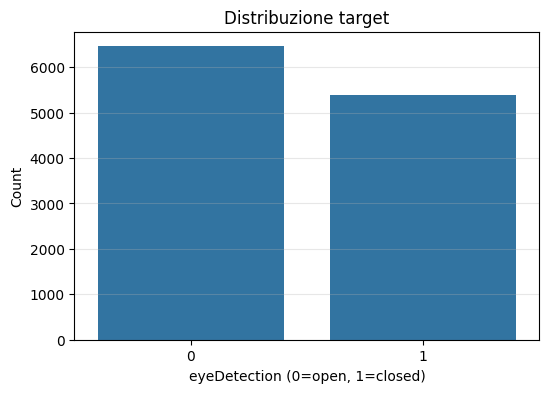

Rapporto di sbilanciamento (majority/minority): 1.196

Statistiche descrittive (prime 10 righe):


,count,mean,std,min,25%,50%,75%,max
AF3,11853.0,4293.354618,18.967673,4234.36,4280.51,4291.79,4304.1,4358.46
F7,11853.0,4003.524012,21.30402,3943.59,3989.23,4002.56,4016.92,4071.28
F3,11853.0,4260.090301,12.543533,4220.0,4250.26,4261.54,4266.67,4301.03
FC5,11853.0,4117.68382,13.792671,4073.33,4107.69,4118.46,4125.13,4168.21
T7,11853.0,4338.551249,9.838536,4308.72,4331.79,4337.95,4345.13,4370.26
P7,11853.0,4618.282933,9.935622,4589.74,4612.82,4617.95,4625.13,4648.72
O1,11853.0,4069.576776,16.938109,4026.15,4056.92,4068.72,4080.51,4122.05
O2,11853.0,4613.926531,12.213846,4575.9,4605.64,4613.33,4622.56,4651.79
P8,11853.0,4199.728256,12.004844,4163.59,4191.79,4199.49,4207.69,4236.41
T8,11853.0,4229.204689,12.482471,4192.31,4221.03,4228.72,4237.44,4267.18


In [4]:
print(f"Dataset shape: {df.shape}")
print(f"Numero feature EEG: {len(feature_cols)}")
print(f"Missing totali: {int(df.isna().sum().sum())}")

class_counts = df["eyeDetection"].value_counts().sort_index()
class_ratio = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="eyeDetection", ax=ax)
ax.set_title("Distribuzione target")
ax.set_xlabel("eyeDetection (0=open, 1=closed)")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
plt.show()

print(f"Rapporto di sbilanciamento (majority/minority): {class_ratio:.3f}")
print("\nStatistiche descrittive (prime 10 righe):")
display(df.describe().T.head(10))

## 5) Distribuzioni per canale (grezze e compresse in scala log)

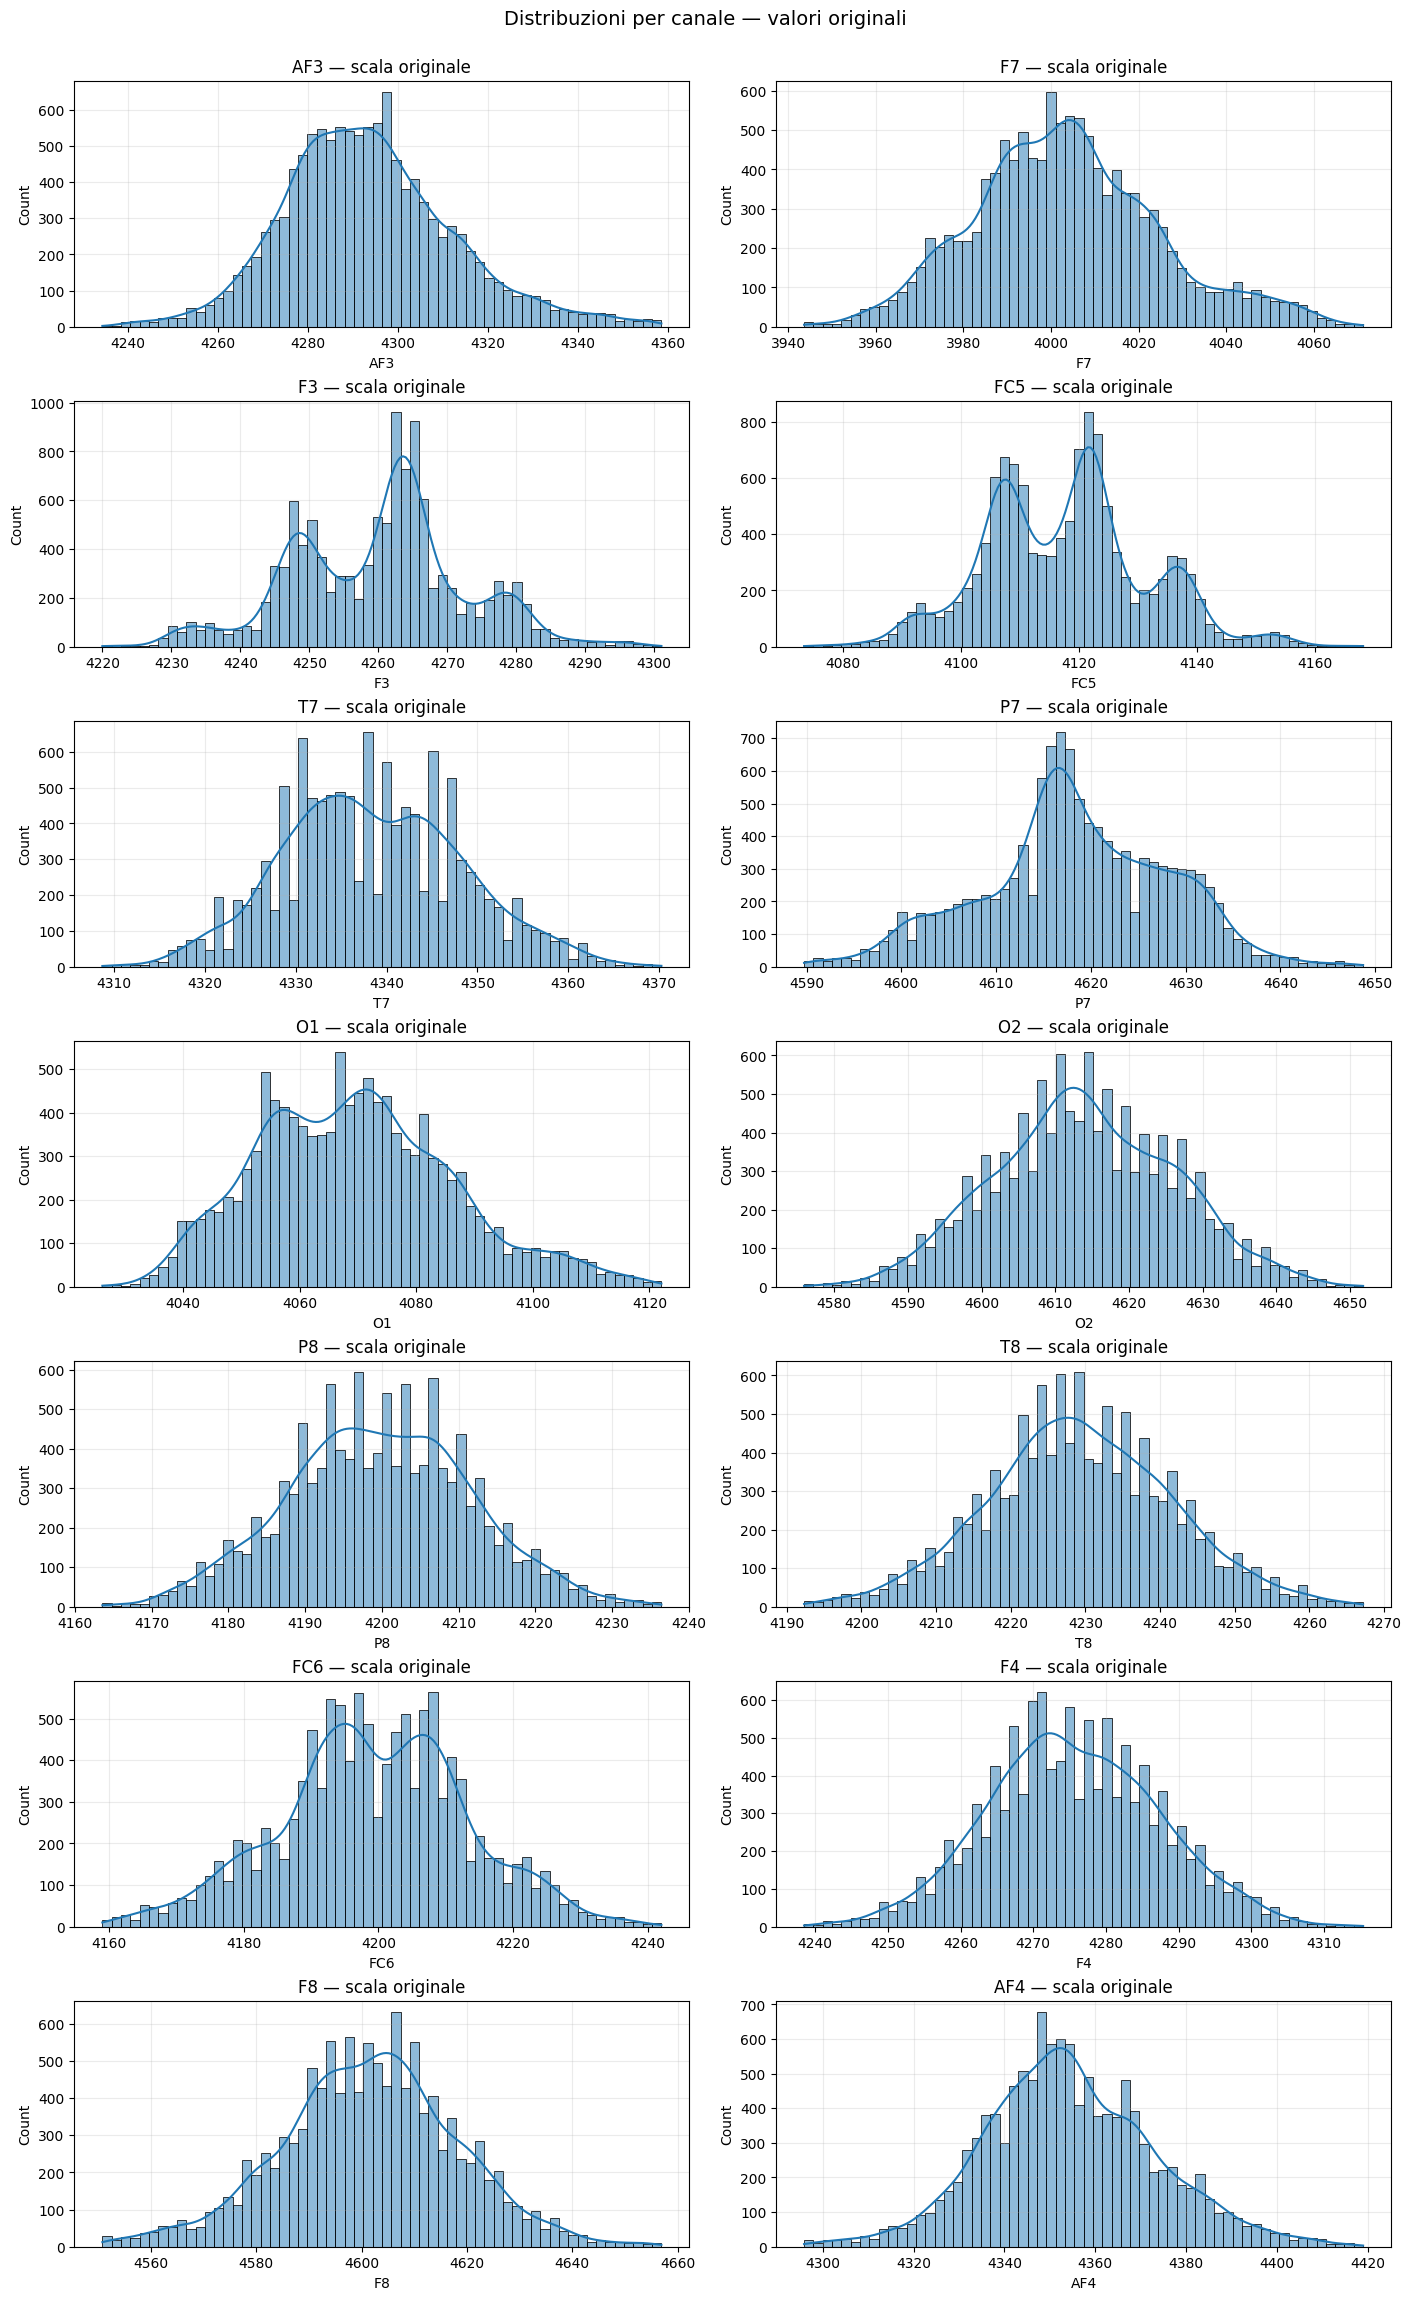

In [5]:
# Variante utile del secondo notebook: istogrammi per canale.
# Qui aggiungiamo anche una trasformazione log 'safe' per leggere meglio le code.

n_cols = 2
n_rows = math.ceil(len(feature_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} — scala originale")
    axes[i].grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuzioni per canale — valori originali", y=1.02, fontsize=14)
plt.show()

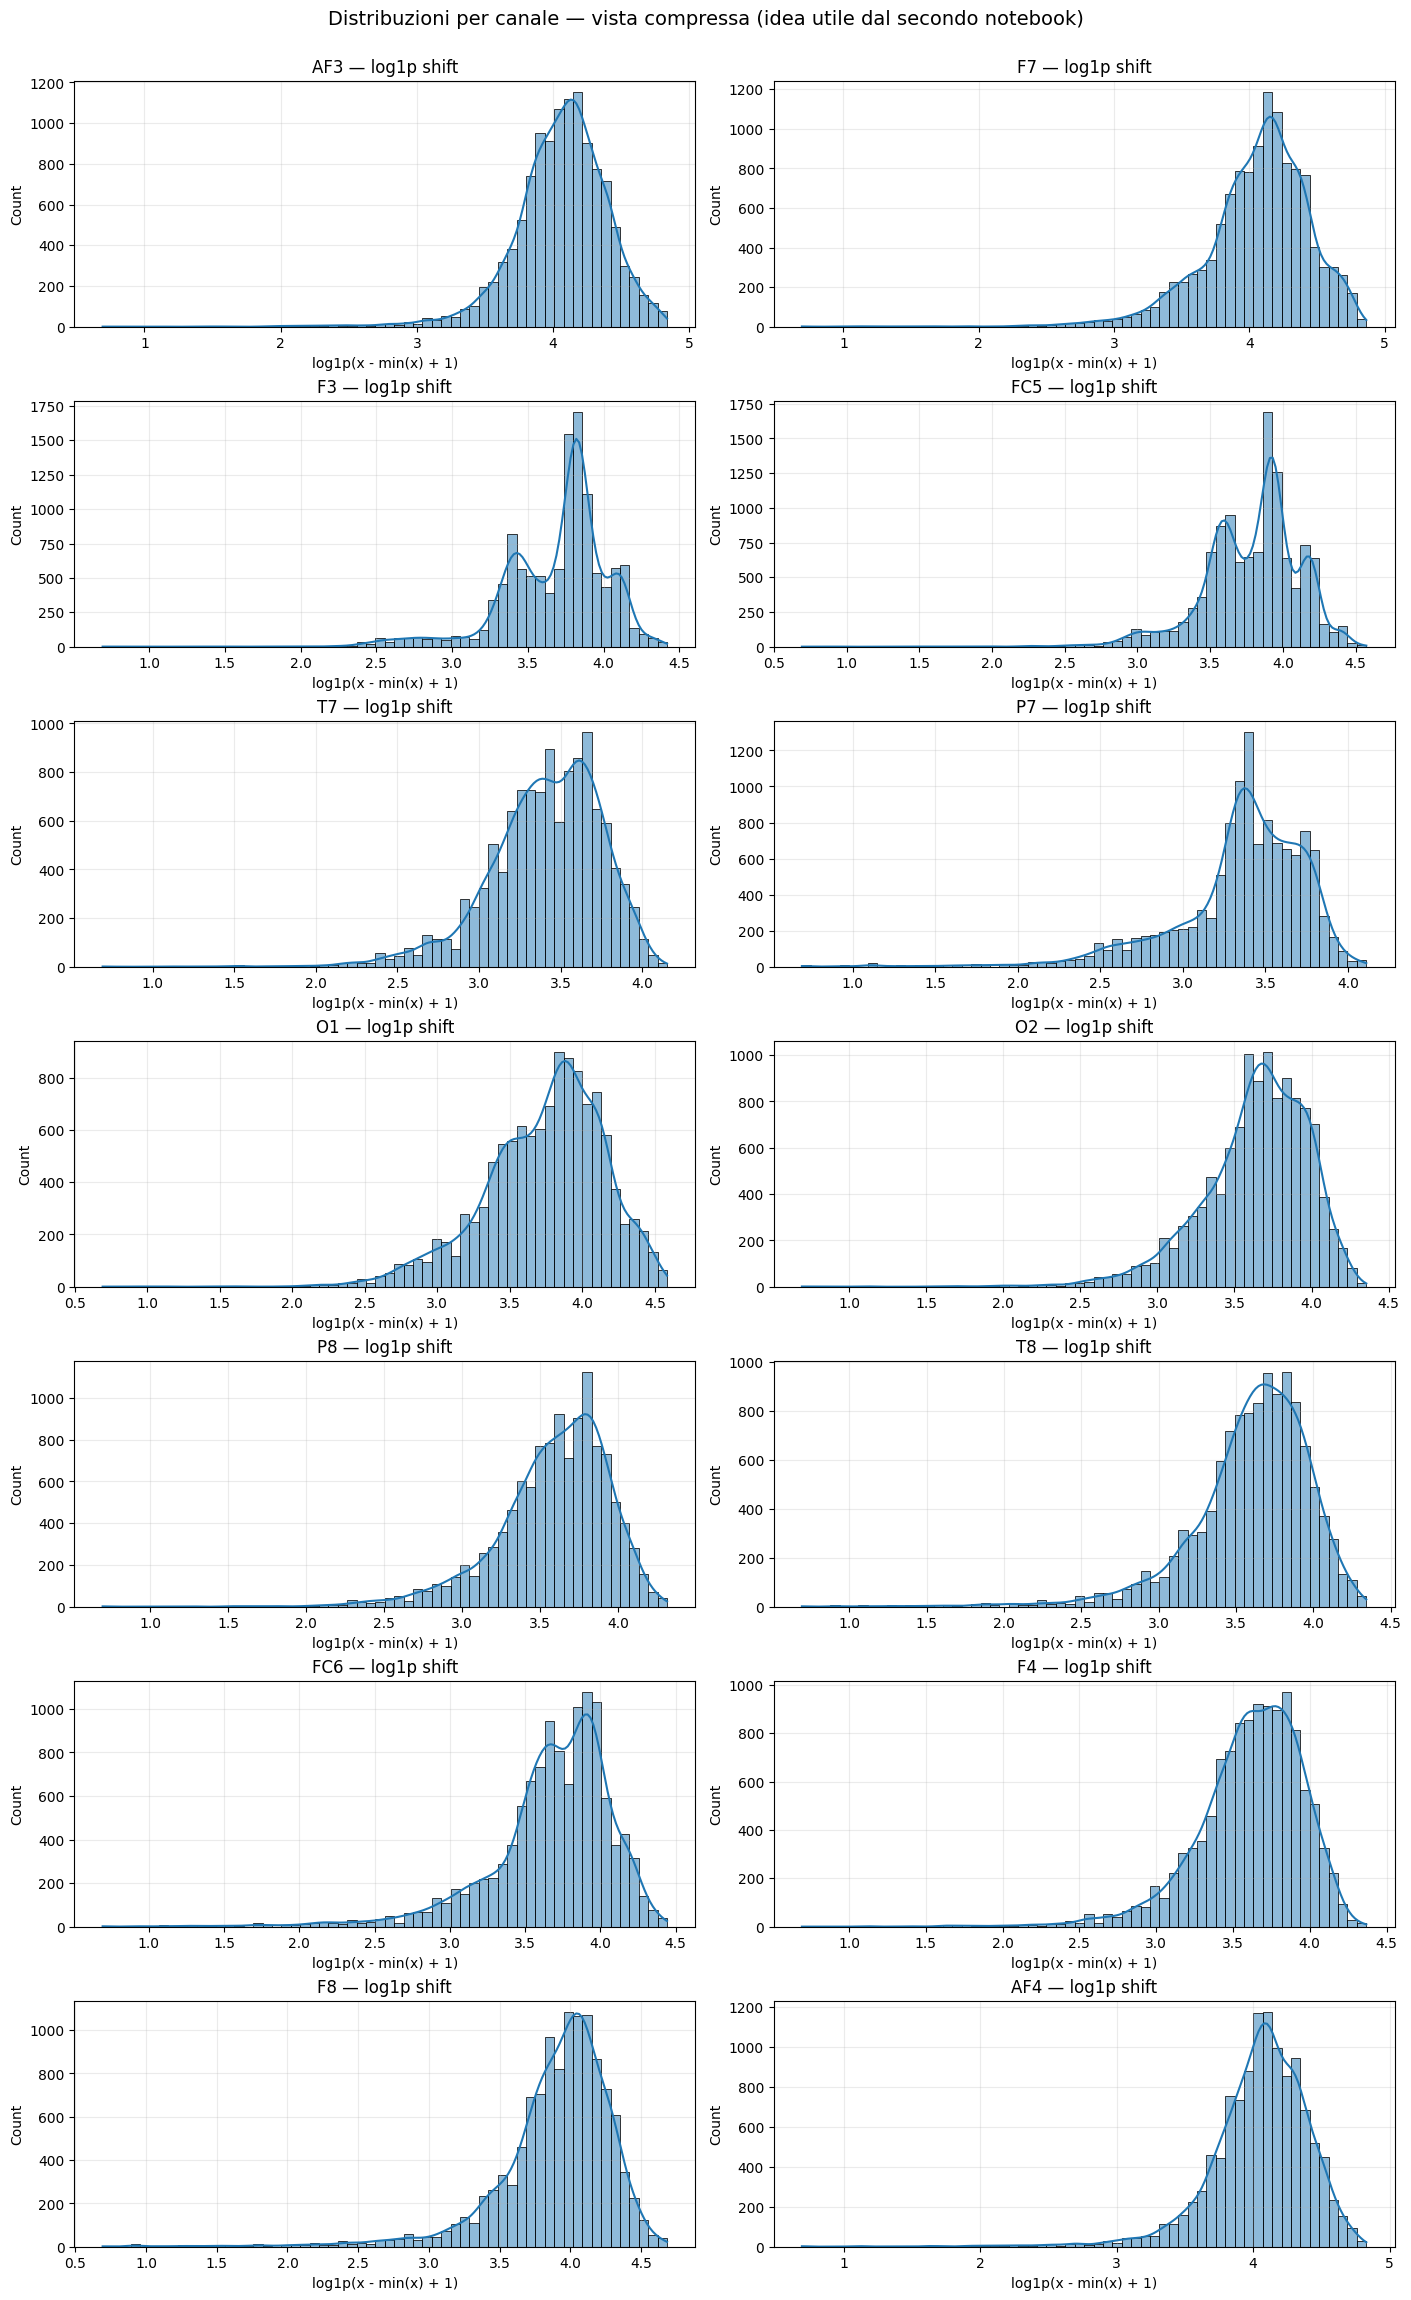

In [6]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_cols):
    shifted = df[col] - df[col].min() + 1.0
    sns.histplot(np.log1p(shifted), bins=60, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} — log1p shift")
    axes[i].set_xlabel("log1p(x - min(x) + 1)")
    axes[i].grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuzioni per canale — vista compressa (idea utile dal secondo notebook)", y=1.02, fontsize=14)
plt.show()

## 6) Correlazioni e confronto tra classi

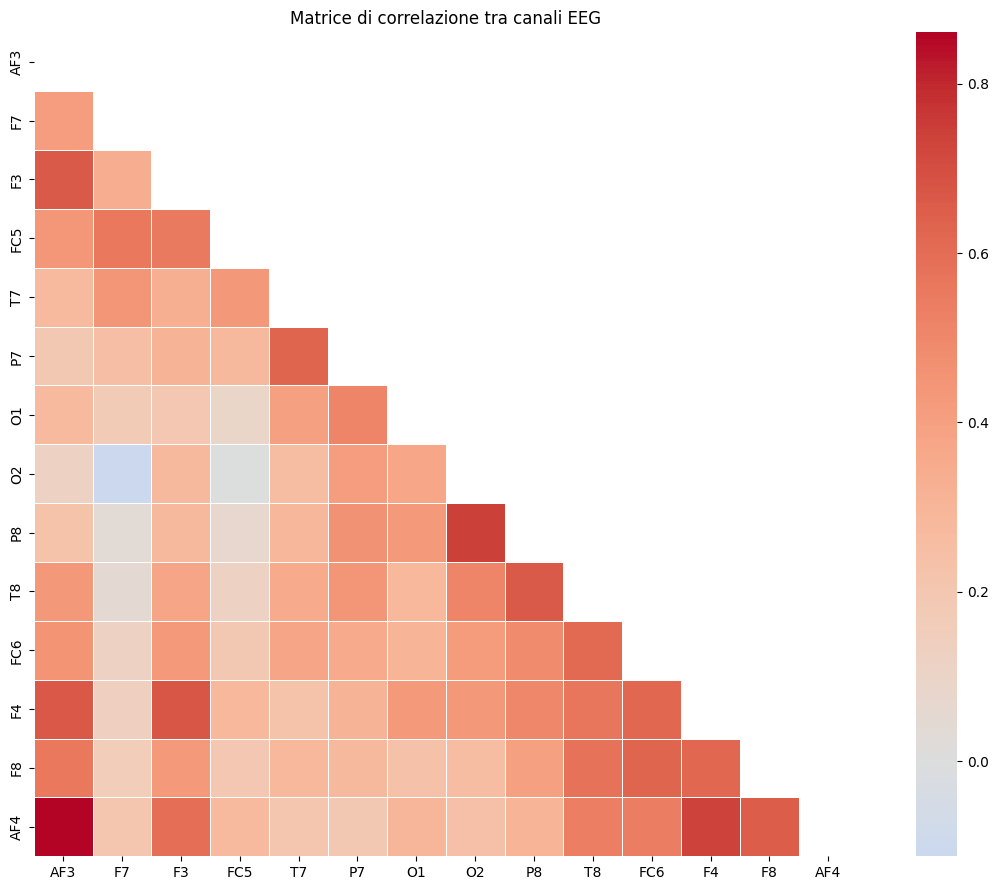

Correlazione con il target (ordinate per valore assoluto):


,corr_with_target
P7,-0.232555
AF4,0.208471
AF3,0.197221
F8,0.128068
F4,0.126633
F3,0.097953
FC6,0.059582
F7,-0.054008
T7,-0.053053
T8,0.044927


In [7]:
corr = df[feature_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True, linewidths=0.4)
plt.title("Matrice di correlazione tra canali EEG")
plt.tight_layout()
plt.show()

corr_with_target = df[feature_cols].corrwith(df["eyeDetection"]).sort_values(key=np.abs, ascending=False)
print("Correlazione con il target (ordinate per valore assoluto):")
display(corr_with_target.to_frame("corr_with_target"))

,mean_open,mean_closed,mean_diff_closed_minus_open,cohens_d
P7,4620.395437,4615.755913,-4.639524,-0.480102
AF4,4350.754958,4358.734404,7.979446,0.427985
AF3,4289.934487,4297.445848,7.511360,0.403925
F8,4599.381637,4603.742639,4.361001,0.259278
F4,4274.118685,4277.128358,3.009673,0.256325
F3,4258.966952,4261.434074,2.467123,0.197627
FC6,4198.502127,4200.191290,1.689163,0.119844
F7,4004.575960,4002.265651,-2.310309,-0.108599
T7,4339.028467,4337.980391,-1.048076,-0.106673
T8,4228.691963,4229.818023,1.126060,0.090299


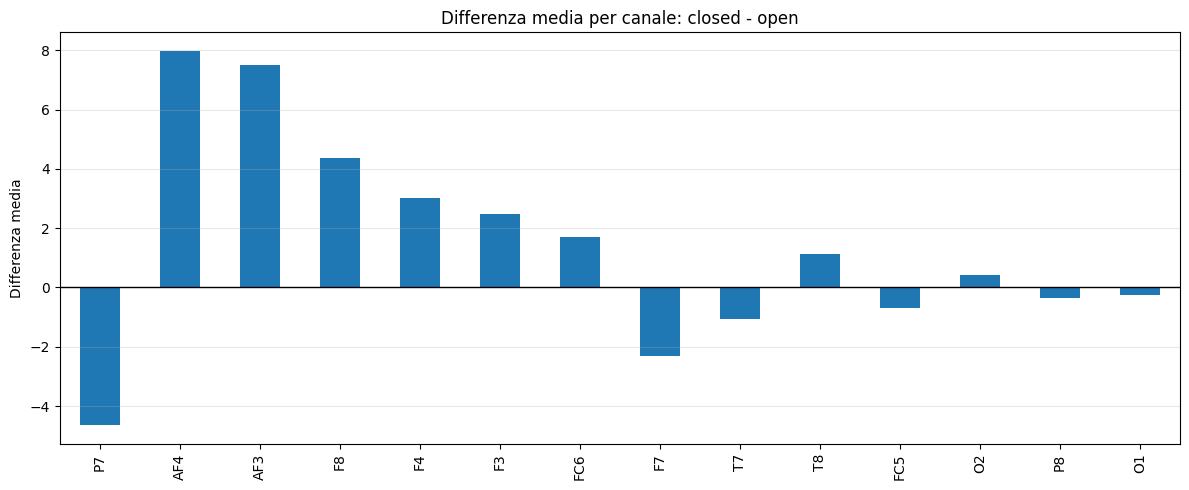

In [8]:
# Manteniamo l'idea buona del secondo notebook: confronto tra classi per canale.
# La rendiamo più rigorosa aggiungendo anche una misura di effetto standardizzata (Cohen's d).

group_stats = df.groupby("eyeDetection")[feature_cols].agg(["mean", "std"])
mean_open = df.loc[df["eyeDetection"] == 0, feature_cols].mean()
mean_closed = df.loc[df["eyeDetection"] == 1, feature_cols].mean()
std_open = df.loc[df["eyeDetection"] == 0, feature_cols].std()
std_closed = df.loc[df["eyeDetection"] == 1, feature_cols].std()
n_open = (df["eyeDetection"] == 0).sum()
n_closed = (df["eyeDetection"] == 1).sum()

pooled_std = np.sqrt(((n_open - 1) * (std_open ** 2) + (n_closed - 1) * (std_closed ** 2)) / (n_open + n_closed - 2))
cohens_d = ((mean_closed - mean_open) / pooled_std).replace([np.inf, -np.inf], np.nan)

effect_df = pd.DataFrame({
    "mean_open": mean_open,
    "mean_closed": mean_closed,
    "mean_diff_closed_minus_open": mean_closed - mean_open,
    "cohens_d": cohens_d,
}).sort_values("cohens_d", key=np.abs, ascending=False)

display(effect_df)

plt.figure(figsize=(12, 5))
effect_df["mean_diff_closed_minus_open"].plot(kind="bar")
plt.axhline(0, color="black", linewidth=1)
plt.title("Differenza media per canale: closed - open")
plt.ylabel("Differenza media")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7) Nota metodologica: cosa **non** facciamo nella pipeline principale

Nel secondo notebook compaiono idee interessanti (filtro, windowing, PSD, feature engineering temporale), ma qui **non le usiamo nella pipeline principale** per tre motivi:

1. aumentano molto la complessità;
2. rischiano leakage se applicate/sele-zionate globalmente prima dello split;
3. cambiano l'unità di analisi del problema.

Per una soluzione d'esame o progetto più solida, è meglio:
- usare prima una pipeline pulita end-to-end;
- aggiungere poi controlli di robustezza separati.

## 8) Split e preprocessing per il benchmark principale

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df[feature_cols].copy()
y = df["eyeDetection"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuzione target:")
print("train:", y_train.value_counts(normalize=True).sort_index().round(3).to_dict())
print("test :", y_test.value_counts(normalize=True).sort_index().round(3).to_dict())

X_train: (9482, 14)
X_test : (2371, 14)

Distribuzione target:
train: {0: 0.545, 1: 0.455}
test : {0: 0.544, 1: 0.456}


## 9) Definizione modelli e spazi di ricerca

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, ParameterGrid
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, brier_score_loss, log_loss
)

models = {
    "LogisticRegression": LogisticRegression(
        random_state=RANDOM_STATE,
        solver="lbfgs",
        max_iter=2000
    ),
    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

param_spaces = {
    "LogisticRegression": {
        "classifier__C": [0.1, 1.0, 10.0, 30.0],
    },
    "RandomForest": {
        "classifier__n_estimators": [200, 400],
        "classifier__max_depth": [None, 8, 16],
        "classifier__min_samples_leaf": [1, 2, 5],
        "classifier__max_features": ["sqrt", 0.7],
    },
    "HistGradientBoosting": {
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [None, 6],
        "classifier__max_leaf_nodes": [15, 31],
        "classifier__min_samples_leaf": [20, 50],
    },
}

# Modelli opzionali: XGBoost e CatBoost.
# Li aggiungiamo solo se disponibili, senza rendere il notebook fragile.
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_estimators=300,
        verbosity=0
    )
    param_spaces["XGBoost"] = {
        "classifier__n_estimators": [200, 400],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [3, 5],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
    }
    print("XGBoost disponibile: incluso nel confronto.")
except Exception:
    print("XGBoost non disponibile: salto questo modello.")

try:
    from catboost import CatBoostClassifier
    models["CatBoost"] = CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    )
    param_spaces["CatBoost"] = {
        "classifier__iterations": [200, 400],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__depth": [4, 6, 8],
        "classifier__l2_leaf_reg": [3, 5, 7],
    }
    print("CatBoost disponibile: incluso nel confronto.")
except Exception:
    print("CatBoost non disponibile: salto questo modello.")

print("\nModelli inclusi:")
for name in models:
    print("-", name)

XGBoost disponibile: incluso nel confronto.
CatBoost non disponibile: salto questo modello.

Modelli inclusi:
- LogisticRegression
- RandomForest
- HistGradientBoosting
- XGBoost


## 10) Tuning con cross-validation (benchmark principale)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(estimator, X_te, y_te):
    y_pred = estimator.predict(X_te)
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_te)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(X_te)
    else:
        y_score = y_pred

    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
    }
    if np.unique(y_te).size >= 2:
        metrics["roc_auc"] = roc_auc_score(y_te, y_score)
    else:
        metrics["roc_auc"] = np.nan
    return metrics

search_results = {}
rows = []

for model_name, model in models.items():
    print("\n" + "=" * 90)
    print(f"Tuning: {model_name}")
    print("=" * 90)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

    grid_size = len(list(ParameterGrid(param_spaces[model_name])))
    n_iter = min(12, grid_size)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[model_name],
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )

    search.fit(X_train, y_train)
    metrics = evaluate_model(search.best_estimator_, X_test, y_test)

    search_results[model_name] = {
        "search": search,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "cv_best_roc_auc": search.best_score_,
        "test_metrics": metrics,
    }

    row = {
        "model": model_name,
        "cv_best_roc_auc": search.best_score_,
        **metrics,
    }
    rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values(
    by=["roc_auc", "f1", "balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)


Tuning: LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Tuning: RandomForest
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tuning: HistGradientBoosting
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tuning: XGBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,model,cv_best_roc_auc,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.979932,0.941797,0.940348,0.946869,0.924074,0.935333,0.987191
1,RandomForest,0.966437,0.930409,0.928378,0.939481,0.905556,0.922207,0.977664
2,HistGradientBoosting,0.964578,0.911008,0.909125,0.914204,0.887963,0.900892,0.973023
3,LogisticRegression,0.735726,0.701814,0.694780,0.694880,0.615741,0.652921,0.755410


## 11) Miglior modello, ROC curve e importanza feature

Miglior modello sul benchmark principale: XGBoost
Best params:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 400, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}

Metriche test:
{'accuracy': 0.9417967102488402, 'balanced_accuracy': 0.9403484235591129, 'precision': 0.9468690702087287, 'recall': 0.924074074074074, 'f1': 0.9353327085285849, 'roc_auc': 0.9871912384886824}


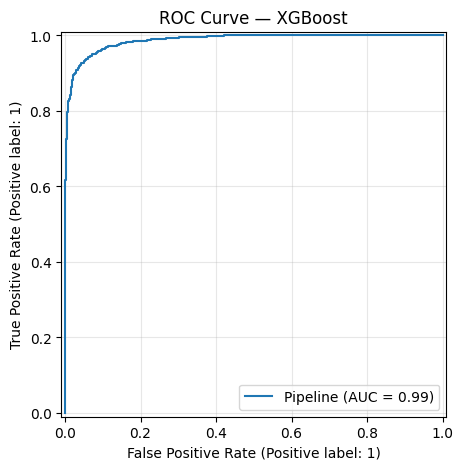

,feature,perm_importance_mean,perm_importance_std
6,O1,0.112792,0.003895
5,P7,0.098303,0.003759
1,F7,0.079631,0.003712
12,F8,0.068428,0.004394
0,AF3,0.059855,0.004071
11,F4,0.040471,0.002163
7,O2,0.030815,0.002025
2,F3,0.026241,0.001937
10,FC6,0.020725,0.001370
13,AF4,0.020474,0.001945


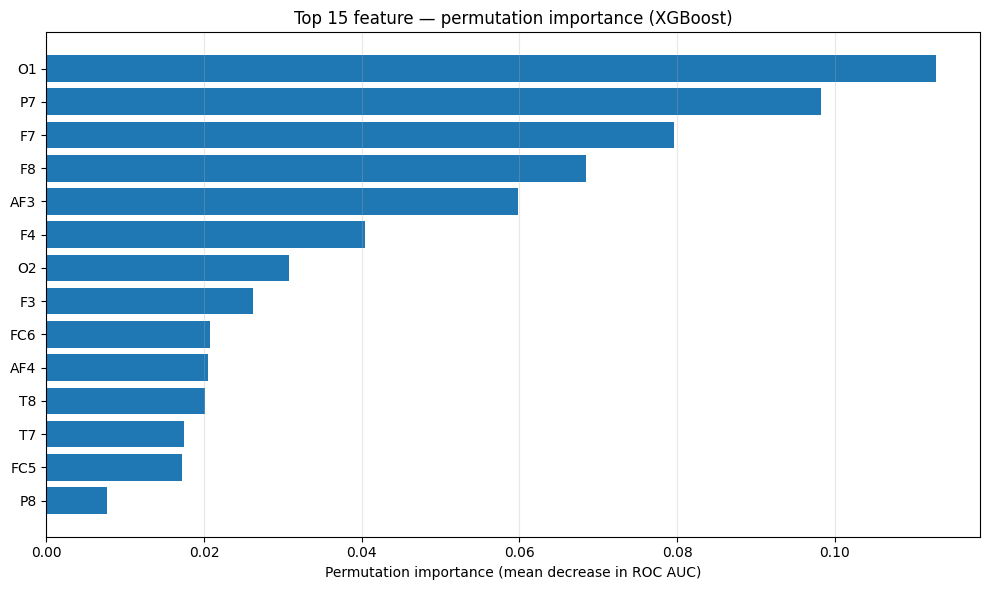

In [12]:
from sklearn.metrics import RocCurveDisplay
from sklearn.inspection import permutation_importance

best_model_name = comparison_df.loc[0, "model"]
best_estimator = search_results[best_model_name]["best_estimator"]

print(f"Miglior modello sul benchmark principale: {best_model_name}")
print("Best params:")
print(search_results[best_model_name]["best_params"])
print("\nMetriche test:")
print(search_results[best_model_name]["test_metrics"])

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_estimator, X_test, y_test, ax=ax)
ax.set_title(f"ROC Curve — {best_model_name}")
ax.grid(alpha=0.3)
plt.show()

perm = permutation_importance(
    best_estimator,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="roc_auc",
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

display(perm_df.head(15))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(15).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["perm_importance_mean"])
plt.xlabel("Permutation importance (mean decrease in ROC AUC)")
plt.title(f"Top 15 feature — permutation importance ({best_model_name})")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Top 15 importanze native:


,feature,native_importance
5,P7,0.118130
6,O1,0.113107
12,F8,0.084958
11,F4,0.075879
1,F7,0.074864
13,AF4,0.073713
0,AF3,0.073649
2,F3,0.062480
7,O2,0.060949
3,FC5,0.060322


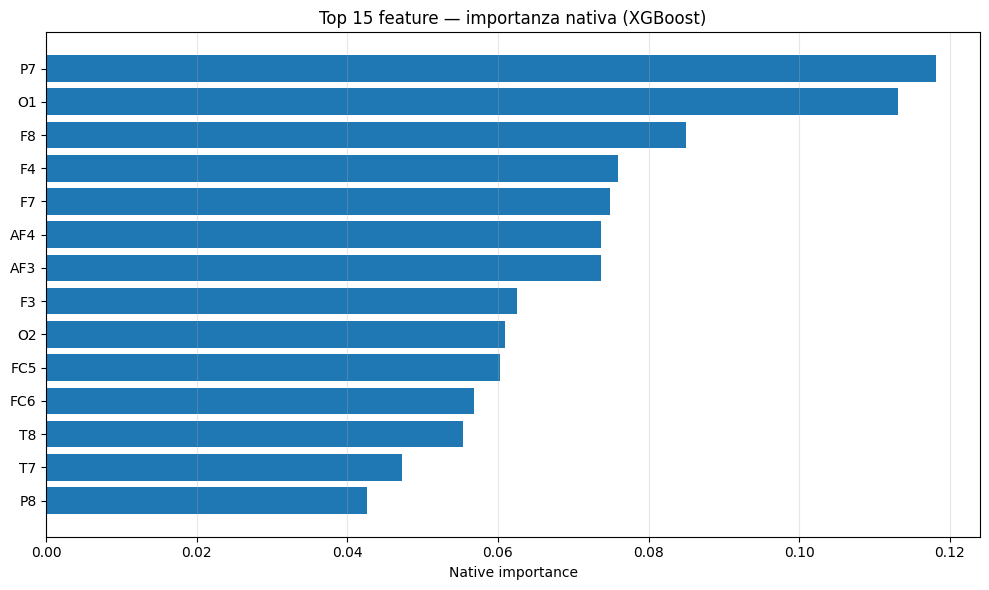

In [13]:
# Importanza nativa / coefficienti, quando disponibili
best_classifier = best_estimator.named_steps["classifier"]

native_importance_df = None

if hasattr(best_classifier, "feature_importances_"):
    native_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "native_importance": best_classifier.feature_importances_,
    }).sort_values("native_importance", ascending=False)

    print("Top 15 importanze native:")
    display(native_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top_native = native_importance_df.head(15).iloc[::-1]
    plt.barh(top_native["feature"], top_native["native_importance"])
    plt.xlabel("Native importance")
    plt.title(f"Top 15 feature — importanza nativa ({best_model_name})")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

elif hasattr(best_classifier, "coef_"):
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "abs_coef": np.abs(best_classifier.coef_[0]),
        "coef": best_classifier.coef_[0],
    }).sort_values("abs_coef", ascending=False)

    print("Top 15 coefficienti assoluti:")
    display(coef_df.head(15))

    plt.figure(figsize=(10, 6))
    top_coef = coef_df.head(15).iloc[::-1]
    plt.barh(top_coef["feature"], top_coef["coef"])
    plt.xlabel("Coefficient")
    plt.title(f"Top 15 coefficienti ({best_model_name})")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il classificatore migliore non espone importanze native semplici.")

## 12) Controllo di robustezza temporale (idea buona del secondo notebook, resa più prudente)

In [14]:
# Il dataset è sequenziale. Per controllare che il modello non stia beneficiando troppo
# dello shuffle casuale, facciamo un test aggiuntivo: train sulle prime osservazioni,
# test sulle ultime osservazioni.

split_idx = int(len(df) * 0.80)

X_time_train = X.iloc[:split_idx].copy()
y_time_train = y.iloc[:split_idx].copy()
X_time_test = X.iloc[split_idx:].copy()
y_time_test = y.iloc[split_idx:].copy()

print("Chronological split")
print("train:", X_time_train.shape, "test:", X_time_test.shape)
print("Target train:", y_time_train.value_counts(normalize=True).sort_index().round(3).to_dict())
print("Target test :", y_time_test.value_counts(normalize=True).sort_index().round(3).to_dict())

# Refit del miglior modello con gli stessi hyperparam trovati nel benchmark principale
best_estimator_time = search_results[best_model_name]["best_estimator"]
best_estimator_time.fit(X_time_train, y_time_train)

time_metrics = evaluate_model(best_estimator_time, X_time_test, y_time_test)

random_metrics = search_results[best_model_name]["test_metrics"]

robustness_df = pd.DataFrame([
    {"evaluation": "random_stratified_test", **random_metrics},
    {"evaluation": "chronological_holdout", **time_metrics},
])

display(robustness_df)

Chronological split
train: (9482, 14) test: (2371, 14)
Target train: {0: 0.445, 1: 0.555}
Target test : {0: 0.943, 1: 0.057}


,evaluation,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,random_stratified_test,0.941797,0.940348,0.946869,0.924074,0.935333,0.987191
1,chronological_holdout,0.482919,0.553089,0.068146,0.632353,0.123033,0.549635


### Lettura del controllo temporale
- Se le metriche sul blocco cronologico restano simili, il modello è più convincente.
- Se crollano molto, vuol dire che il benchmark con split casuale era ottimistico e che la dipendenza temporale conta davvero.

Questo è il modo più sicuro per incorporare l'osservazione utile del secondo notebook senza introdurre una pipeline troppo fragile.

## 12-bis) Validazione temporale a blocchi (più rigorosa del singolo holdout)

Per rendere la valutazione più difendibile, aggiungiamo una **expanding/blocked time CV** sul modello tabellare migliore.  
L'idea è semplice: ogni fold allena sul passato e valida su un blocco successivo, senza shuffle.


In [15]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=5, test_size=max(1, len(X) // 10))
blocked_rows = []

for fold_id, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    fold_estimator = clone(best_estimator)
    X_fold_train, y_fold_train = X.iloc[train_idx], y.iloc[train_idx]
    X_fold_val, y_fold_val = X.iloc[val_idx], y.iloc[val_idx]
    fold_estimator.fit(X_fold_train, y_fold_train)
    fold_metrics = evaluate_model(fold_estimator, X_fold_val, y_fold_val)
    val_unique_classes = int(np.unique(y_fold_val).size)
    blocked_rows.append({
        "fold": fold_id,
        "train_start": int(train_idx[0]),
        "train_end": int(train_idx[-1]),
        "val_start": int(val_idx[0]),
        "val_end": int(val_idx[-1]),
        "train_closed_rate": float(y_fold_train.mean()),
        "val_closed_rate": float(y_fold_val.mean()),
        "val_n_classes": val_unique_classes,
        "roc_auc_defined": bool(val_unique_classes >= 2),
        **fold_metrics,
    })

blocked_chrono_cv_df = pd.DataFrame(blocked_rows)
display(blocked_chrono_cv_df)

if (~blocked_chrono_cv_df["roc_auc_defined"]).any():
    print("Warning: in some chronological folds the validation block contains only one class, so ROC-AUC is undefined there and is reported as NaN. This is expected on strongly shifted / imbalanced time blocks.")

metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
blocked_chrono_summary_df = (
    blocked_chrono_cv_df[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .T.reset_index()
    .rename(columns={"index": "metric"})
)
display(blocked_chrono_summary_df)


,fold,train_start,train_end,val_start,val_end,train_closed_rate,val_closed_rate,val_n_classes,roc_auc_defined,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,1,0,7489,7490,8987,0.534045,1.000000,1,False,0.696929,0.696929,1.000000,0.696929,0.821400,NaN
1,2,0,8987,8988,10485,0.611704,0.044059,2,True,0.116155,0.450990,0.039531,0.818182,0.075419,0.339470
2,3,0,10485,10486,11983,0.530612,0.586782,2,True,0.574099,0.519058,0.598047,0.836177,0.697343,0.589788
3,4,0,11983,11984,13481,0.537634,0.124833,2,True,0.449933,0.594040,0.157895,0.786096,0.262970,0.667735
4,5,0,13481,13482,14979,0.491767,0.062083,2,True,0.680908,0.538706,0.076923,0.376344,0.127737,0.448812


,metric,mean,std,min,max
0,accuracy,0.503605,0.238106,0.116155,0.696929
1,balanced_accuracy,0.559945,0.092088,0.450990,0.696929
2,precision,0.374479,0.414999,0.039531,1.000000
3,recall,0.702746,0.190164,0.376344,0.836177
4,f1,0.396974,0.340662,0.075419,0.821400
5,roc_auc,0.511451,0.146131,0.339470,0.667735


## 13) Estensione deep learning time-aware su finestre EEG

Le architetture deep che sfruttano convoluzioni temporali, ricorrenza o attention **non sono metodologicamente appropriate sulla singola riga isolata**.  
Per questo apriamo un **ramo separato** del notebook, coerente con la natura sequenziale del dataset.

In questa versione il ramo deep viene ulteriormente potenziato **senza introdurre ensemble**:

1. **finestre più lunghe** (`WINDOW_SIZE=64`) per dare più contesto ai modelli temporali;
2. **training più lungo e più stabile** (`MAX_EPOCHS=200`, `LR=1e-4`, scheduler più paziente);
3. **augmentation più ricca**:
   - jitter gaussiano,
   - gain jitter,
   - time shift,
   - time masking,
   - **frequency masking**,
   - **mixup e cutmix temporale**;
4. **feature EEG multi-band**: appendiamo canali sintetici PSD su `P7`, `O1`, `O2` per bande `theta`, `alpha`, `beta`;
5. **TCFormer più vicino alla famiglia originale**: front-end multi-kernel più capace, blocchi Transformer custom con **RoPE**, head TCN più profonda;
6. **SWA** (*stochastic weight averaging*) come raffinamento finale opzionale;
7. **quantizzazione dinamica post-training** per benchmark CPU / low-latency.

Manteniamo però i principi corretti già fissati:

- facciamo lo **split cronologico prima del windowing**, così evitiamo leakage tra train/validation/test;
- etichettiamo ogni finestra con il **label dell'ultimo istante** (`label_mode="last"`), sensato in scenario quasi real-time;
- la soglia finale resta scelta su **validation**, non sul test cronologico.


In [16]:
# =========================
# Deep learning time-aware
# =========================
from dataclasses import dataclass
import copy
import time
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
import torch.nn.utils.prune as prune

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

# Configurazione più orientata al deployment cronologico:
# - più contesto temporale
# - stride più fitto
# - training più lungo ma regolarizzato
WINDOW_SIZE = 64
TRAIN_STRIDE = 2
EVAL_STRIDE = 2
FS_EEG = 128
BATCH_SIZE = 256

MAX_EPOCHS = 120
PATIENCE = 18
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 3e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 8

FOCAL_ALPHA = None
FOCAL_GAMMA = 1.5
FOCAL_GAMMA_CANDIDATES = [1.0, 1.5, 2.0]
ENABLE_FOCAL_GAMMA_SWEEP = True
FOCAL_SWEEP_EPOCHS = 10
FOCAL_SWEEP_PATIENCE = 4

# Augmentation più sobria e stabile: meno aggressiva, più adatta a non distruggere il segnale.
NOISE_STD = 0.01
GAIN_STD = 0.03
CHANNEL_DROPOUT_P = 0.05
MAX_TIME_SHIFT = 2
TIME_SHIFT_P = 0.60
TIME_MASK_P = 0.35
MAX_TIME_MASK_WIDTH = 8
FREQ_MASK_P = 0.25
MAX_FREQ_MASK_WIDTH = 2
MIXUP_ALPHA = 0.20
MIXUP_P = 0.25
CUTMIX_ALPHA = 1.00
CUTMIX_P = 0.15
CUTMIX_MIN_RATIO = 0.10
CUTMIX_MAX_RATIO = 0.30

USE_TTA = True
TTA_VARIANTS = 3
BENCHMARK_BATCH_SIZE = 64
BENCHMARK_N_BATCHES = 20
BENCHMARK_USE_TTA = False
TTA_NOISE_STD = 0.003
TTA_MAX_SHIFT = 1
TTA_GAIN_STD = 0.01

# Post-processing meno aggressivo: cerchiamo più equilibrio precision/recall.
USE_PROB_SMOOTHING = True
PROB_SMOOTH_ALPHA = 0.18
USE_HYSTERESIS = True
HYSTERESIS_GAP = 0.08

USE_SWA = True
SWA_START_PCT = 0.75
SWA_LR = 1e-4

# Impostazioni più conservative per evitare bias o pruning del train troppo aggressivi.
MANUAL_POS_WEIGHT_OVERRIDE = None
TARGET_THRESHOLD_FALLBACK = 0.55

USE_WINDOW_CHANNEL_ZSCORE = True
WINDOW_ZSCORE_RAW_CHANNELS = len(feature_cols)

USE_TRAIN_ONLY_POSITIVE_CLEANING = False
POSITIVE_CLEAN_MIN_PROBA = 0.60
POSITIVE_CLEAN_MAX_DROP_FRAC = 0.15
POSITIVE_CLEAN_MODEL = "logreg"

USE_BALANCED_SAMPLER = True

PRETRAIN_CHECKPOINTS = {
    "CNN_BiLSTM_Attention": None,
    "EEGNet": None,
    "EEGNet_Plus": None,
    "TCFormer": None,
}
ALLOW_PARTIAL_PRETRAIN = True

ENABLE_QUANTIZATION_BENCH = True
ENABLE_PRUNING_BENCH = True
PRUNING_AMOUNT = 0.20
QUANTIZATION_MODELS = ["EEGNet", "EEGNet_Plus", "CNN_BiLSTM_Attention"]

THRESHOLD_GRID = np.round(np.linspace(0.10, 0.90, 33), 2)
THRESHOLD_POLICY = "precision_floor"
THRESHOLD_METRIC = "f0_5"
MIN_PRECISION_CLOSED = 0.55

n_total = len(df)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

X_train_raw = X.iloc[:train_end].copy()
y_train_raw = y.iloc[:train_end].copy()
X_val_raw = X.iloc[train_end:val_end].copy()
y_val_raw = y.iloc[train_end:val_end].copy()
X_test_raw_dl = X.iloc[val_end:].copy()
y_test_raw_dl = y.iloc[val_end:].copy()

print("Split cronologico per il ramo deep:")
print("train:", X_train_raw.shape, y_train_raw.value_counts(normalize=True).sort_index().round(3).to_dict())
print("val  :", X_val_raw.shape, y_val_raw.value_counts(normalize=True).sort_index().round(3).to_dict())
print("test :", X_test_raw_dl.shape, y_test_raw_dl.value_counts(normalize=True).sort_index().round(3).to_dict())


PyTorch: 2.10.0+cpu
Device : cpu
Split cronologico per il ramo deep:
train: (10486, 14) {0: 0.469, 1: 0.531}
val  : (2247, 14) {0: 0.566, 1: 0.434}
test : (2247, 14) {0: 0.919, 1: 0.081}


In [17]:
from scipy.signal import welch
from sklearn.linear_model import LogisticRegression


def standardize_by_train_stats(X_train_df, X_other_dfs):
    train_mean = X_train_df.mean(axis=0)
    train_std = X_train_df.std(axis=0).replace(0, 1.0)
    X_train_scaled = (X_train_df - train_mean) / train_std
    others_scaled = [(X_df - train_mean) / train_std for X_df in X_other_dfs]
    return X_train_scaled, others_scaled, train_mean, train_std


def create_eeg_windows(X_df, y_series, window_size=64, stride=1, label_mode="last"):
    X_np = X_df.to_numpy(dtype=np.float32)
    y_np = y_series.to_numpy(dtype=np.int64)
    windows, labels = [], []
    for start in range(0, len(X_np) - window_size + 1, stride):
        end = start + window_size
        window = X_np[start:end].T
        target_slice = y_np[start:end]
        if label_mode == "last":
            label = int(target_slice[-1])
        elif label_mode == "majority":
            label = int(np.round(target_slice.mean()))
        else:
            raise ValueError("label_mode deve essere 'last' oppure 'majority'.")
        windows.append(window)
        labels.append(label)
    return np.stack(windows).astype(np.float32), np.array(labels, dtype=np.int64)


def append_psd_multiband_channels(X_windows, fs=128, channel_map=None, band_map=None):
    """
    Aggiunge canali sintetici costanti nel tempo con feature EEG derivate per finestra.
    Default:
    - potenza PSD su P7, O1, O2 per bande theta/alpha/beta
    - rapporto alpha/theta sugli stessi canali
    - variabilità intra-finestra su O1 e O2
    - differenza P7-O2 come proxy molto grezzo di componente oculare/posteriore
    input  : [N, C, T]
    output : [N, C + n_feature_sintetiche, T]
    """
    if X_windows.ndim != 3:
        raise ValueError(f"Atteso array 3D [N,C,T], ricevuto shape={X_windows.shape}")
    if channel_map is None:
        channel_map = {"P7": 5, "O1": 6, "O2": 7}
    if band_map is None:
        band_map = {"theta": (4.0, 8.0), "alpha": (8.0, 13.0), "beta": (13.0, 30.0)}

    channel_names = list(channel_map.keys())
    channel_indices = [channel_map[name] for name in channel_names]
    X_sel = X_windows[:, channel_indices, :]
    freqs, psd = welch(X_sel, fs=fs, nperseg=min(X_sel.shape[-1], 64), axis=-1, scaling="density")

    feature_blocks = []
    feature_names = []
    band_power_dict = {}

    for band_name, (f_lo, f_hi) in band_map.items():
        band_mask = (freqs >= f_lo) & (freqs <= f_hi)
        band_power = psd[:, :, band_mask].mean(axis=-1).astype(np.float32)
        band_power_dict[band_name] = band_power
        feature_blocks.append(band_power)
        feature_names.extend([f"{ch}_{band_name}" for ch in channel_names])

    # rapporti alpha/theta per P7, O1, O2
    eps = 1e-8
    alpha_theta_ratio = (band_power_dict["alpha"] / (band_power_dict["theta"] + eps)).astype(np.float32)
    feature_blocks.append(alpha_theta_ratio)
    feature_names.extend([f"{ch}_alpha_theta_ratio" for ch in channel_names])

    # variabilità temporale su O1/O2
    o1_idx = channel_names.index("O1")
    o2_idx = channel_names.index("O2")
    o1_var = X_sel[:, o1_idx, :].var(axis=-1, keepdims=True).astype(np.float32)
    o2_var = X_sel[:, o2_idx, :].var(axis=-1, keepdims=True).astype(np.float32)
    feature_blocks.extend([o1_var, o2_var])
    feature_names.extend(["O1_var", "O2_var"])

    # differenza media assoluta P7-O2
    p7_idx = channel_names.index("P7")
    p7_o2_diff = np.mean(np.abs(X_sel[:, p7_idx, :] - X_sel[:, o2_idx, :]), axis=-1, keepdims=True).astype(np.float32)
    feature_blocks.append(p7_o2_diff)
    feature_names.append("P7_O2_absdiff")

    feat_stack = np.concatenate(feature_blocks, axis=1).astype(np.float32)
    synth_channels = np.repeat(feat_stack[:, :, None], X_windows.shape[-1], axis=-1)
    X_aug = np.concatenate([X_windows, synth_channels], axis=1).astype(np.float32)
    return X_aug, pd.DataFrame(feat_stack, columns=feature_names)


def window_channelwise_zscore(X_windows, n_raw_channels=14, eps=1e-6):
    X_out = np.array(X_windows, dtype=np.float32, copy=True)
    n_raw = int(min(max(n_raw_channels, 0), X_out.shape[1]))
    if n_raw <= 0:
        return X_out
    raw = X_out[:, :n_raw, :]
    mu = raw.mean(axis=-1, keepdims=True)
    sigma = raw.std(axis=-1, keepdims=True)
    sigma = np.where(sigma < eps, 1.0, sigma)
    X_out[:, :n_raw, :] = (raw - mu) / sigma
    return X_out


def summarize_windows_for_cleaning(X_windows, n_raw_channels=14):
    n_raw = int(min(max(n_raw_channels, 0), X_windows.shape[1]))
    raw = X_windows[:, :n_raw, :]
    return np.concatenate(
        [
            raw.mean(axis=-1),
            raw.std(axis=-1),
            np.ptp(raw, axis=-1),
        ],
        axis=1,
    ).astype(np.float32)


def train_only_positive_cleaning(X_windows, y_windows, min_proba=0.60, max_drop_frac=0.25, n_raw_channels=14):
    y_arr = np.asarray(y_windows).astype(int)
    if len(np.unique(y_arr)) < 2:
        info = {
            "cleaning_applied": False,
            "reason": "single_class_train_windows",
            "teacher_threshold": np.nan,
            "positive_kept_frac": 1.0,
            "positive_dropped": 0,
        }
        return X_windows, y_windows, None, info

    feats = summarize_windows_for_cleaning(X_windows, n_raw_channels=n_raw_channels)
    teacher = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    teacher.fit(feats, y_arr)
    prob_pos = teacher.predict_proba(feats)[:, 1]

    pos_idx = np.where(y_arr == 1)[0]
    keep_mask = np.ones(len(y_arr), dtype=bool)

    if len(pos_idx) == 0:
        info = {
            "cleaning_applied": False,
            "reason": "no_positive_windows",
            "teacher_threshold": np.nan,
            "positive_kept_frac": 1.0,
            "positive_dropped": 0,
        }
        return X_windows, y_windows, teacher, info

    pos_probs = prob_pos[pos_idx]
    teacher_threshold = float(min_proba)
    keep_pos = pos_probs >= teacher_threshold
    drop_frac = 1.0 - float(np.mean(keep_pos))

    if drop_frac > float(max_drop_frac):
        teacher_threshold = float(np.quantile(pos_probs, float(max_drop_frac)))
        keep_pos = pos_probs >= teacher_threshold

    keep_mask[pos_idx] = keep_pos
    info = {
        "cleaning_applied": True,
        "reason": "train_only_teacher_filter",
        "teacher_threshold": teacher_threshold,
        "positive_kept_frac": float(np.mean(keep_pos)),
        "positive_dropped": int((~keep_pos).sum()),
        "rows_before": int(len(y_arr)),
        "rows_after": int(keep_mask.sum()),
    }
    return X_windows[keep_mask], y_arr[keep_mask].astype(np.int64), teacher, info


class EEGWindowDataset(Dataset):
    def __init__(self, X_windows, y_windows, training=False, noise_std=0.02, gain_std=0.05,
                 channel_dropout_p=0.10, max_time_shift=4, time_shift_p=0.80,
                 time_mask_p=0.50, max_time_mask_width=4, freq_mask_p=0.40,
                 max_freq_mask_width=2):
        self.X = torch.tensor(X_windows, dtype=torch.float32)
        self.y = torch.tensor(y_windows, dtype=torch.float32)
        self.training = training
        self.noise_std = float(noise_std)
        self.gain_std = float(gain_std)
        self.channel_dropout_p = float(channel_dropout_p)
        self.max_time_shift = int(max_time_shift)
        self.time_shift_p = float(time_shift_p)
        self.time_mask_p = float(time_mask_p)
        self.max_time_mask_width = int(max_time_mask_width)
        self.freq_mask_p = float(freq_mask_p)
        self.max_freq_mask_width = int(max_freq_mask_width)

    def __len__(self):
        return len(self.y)

    @staticmethod
    def _temporal_shift(x, shift):
        if shift == 0:
            return x
        out = torch.empty_like(x)
        if shift > 0:
            out[:, :shift] = x[:, :1].expand(-1, shift)
            out[:, shift:] = x[:, :-shift]
        else:
            s = abs(shift)
            out[:, -s:] = x[:, -1:].expand(-1, s)
            out[:, :-s] = x[:, s:]
        return out

    @staticmethod
    def _time_mask(x, width):
        width = max(int(width), 0)
        if width <= 0 or width >= x.shape[-1]:
            return x
        start = torch.randint(low=0, high=x.shape[-1] - width + 1, size=(1,)).item()
        x = x.clone()
        x[:, start:start + width] = 0.0
        return x

    @staticmethod
    def _frequency_mask(x, width):
        n_bins = x.shape[-1] // 2 + 1
        width = min(max(int(width), 0), max(n_bins - 1, 0))
        if width <= 0 or n_bins <= 2:
            return x
        start = torch.randint(low=1, high=max(2, n_bins - width + 1), size=(1,)).item()
        Xf = torch.fft.rfft(x, dim=-1)
        Xf = Xf.clone()
        Xf[:, start:start + width] = 0
        return torch.fft.irfft(Xf, n=x.shape[-1], dim=-1)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.training:
            if self.noise_std > 0:
                x = x + torch.randn_like(x) * self.noise_std
            if self.gain_std > 0:
                x = x * (1.0 + torch.randn(1).item() * self.gain_std)
            if self.max_time_shift > 0 and torch.rand(1).item() < self.time_shift_p:
                shift = int(torch.randint(low=-self.max_time_shift, high=self.max_time_shift + 1, size=(1,)).item())
                x = self._temporal_shift(x, shift)
            if self.max_time_mask_width > 0 and torch.rand(1).item() < self.time_mask_p:
                width = int(torch.randint(low=1, high=self.max_time_mask_width + 1, size=(1,)).item())
                x = self._time_mask(x, width)
            if self.max_freq_mask_width > 0 and torch.rand(1).item() < self.freq_mask_p:
                width = int(torch.randint(low=1, high=self.max_freq_mask_width + 1, size=(1,)).item())
                x = self._frequency_mask(x, width)
            if self.channel_dropout_p > 0 and torch.rand(1).item() < self.channel_dropout_p:
                ch = torch.randint(low=0, high=x.shape[0], size=(1,)).item()
                x[ch] = 0.0
        return x, y


X_train_scaled, [X_val_scaled, X_test_scaled], train_mean_dl, train_std_dl = standardize_by_train_stats(
    X_train_raw, [X_val_raw, X_test_raw_dl]
)
X_train_win, y_train_win = create_eeg_windows(X_train_scaled, y_train_raw, window_size=WINDOW_SIZE, stride=TRAIN_STRIDE, label_mode="last")
X_val_win, y_val_win = create_eeg_windows(X_val_scaled, y_val_raw, window_size=WINDOW_SIZE, stride=EVAL_STRIDE, label_mode="last")
X_test_win, y_test_win = create_eeg_windows(X_test_scaled, y_test_raw_dl, window_size=WINDOW_SIZE, stride=EVAL_STRIDE, label_mode="last")

if USE_WINDOW_CHANNEL_ZSCORE:
    X_train_win = window_channelwise_zscore(X_train_win, n_raw_channels=WINDOW_ZSCORE_RAW_CHANNELS)
    X_val_win = window_channelwise_zscore(X_val_win, n_raw_channels=WINDOW_ZSCORE_RAW_CHANNELS)
    X_test_win = window_channelwise_zscore(X_test_win, n_raw_channels=WINDOW_ZSCORE_RAW_CHANNELS)

X_train_win, train_band_df = append_psd_multiband_channels(X_train_win, fs=FS_EEG)
X_val_win, val_band_df = append_psd_multiband_channels(X_val_win, fs=FS_EEG)
X_test_win, test_band_df = append_psd_multiband_channels(X_test_win, fs=FS_EEG)

cleaning_info = {"cleaning_applied": False, "reason": "disabled"}
positive_clean_teacher = None
if USE_TRAIN_ONLY_POSITIVE_CLEANING:
    X_train_win, y_train_win, positive_clean_teacher, cleaning_info = train_only_positive_cleaning(
        X_train_win,
        y_train_win,
        min_proba=POSITIVE_CLEAN_MIN_PROBA,
        max_drop_frac=POSITIVE_CLEAN_MAX_DROP_FRAC,
        n_raw_channels=WINDOW_ZSCORE_RAW_CHANNELS,
    )

DEEP_N_CHANNELS = X_train_win.shape[1]
print(f"Numero canali input deep dopo PSD multiband patch: {DEEP_N_CHANNELS}")
print("Finestre create:")
print("X_train_win:", X_train_win.shape, "target:", pd.Series(y_train_win).value_counts(normalize=True).sort_index().round(3).to_dict())
print("X_val_win  :", X_val_win.shape, "target:", pd.Series(y_val_win).value_counts(normalize=True).sort_index().round(3).to_dict())
print("X_test_win :", X_test_win.shape, "target:", pd.Series(y_test_win).value_counts(normalize=True).sort_index().round(3).to_dict())

psd_summary_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    **{col: [float(train_band_df[col].mean()), float(val_band_df[col].mean()), float(test_band_df[col].mean())] for col in train_band_df.columns},
})
display(psd_summary_df)

cleaning_summary_df = pd.DataFrame([cleaning_info])
display(cleaning_summary_df)

train_ds = EEGWindowDataset(X_train_win, y_train_win, training=True, noise_std=NOISE_STD, gain_std=GAIN_STD,
                            channel_dropout_p=CHANNEL_DROPOUT_P, max_time_shift=MAX_TIME_SHIFT,
                            time_shift_p=TIME_SHIFT_P, time_mask_p=TIME_MASK_P,
                            max_time_mask_width=MAX_TIME_MASK_WIDTH, freq_mask_p=FREQ_MASK_P,
                            max_freq_mask_width=MAX_FREQ_MASK_WIDTH)
val_ds = EEGWindowDataset(X_val_win, y_val_win, training=False)
test_ds = EEGWindowDataset(X_test_win, y_test_win, training=False)

if USE_BALANCED_SAMPLER:
    class_counts = np.bincount(y_train_win.astype(int), minlength=2).astype(np.float64)
    class_weights = np.zeros_like(class_counts, dtype=np.float64)
    nonzero_mask = class_counts > 0
    class_weights[nonzero_mask] = 1.0 / class_counts[nonzero_mask]
    sample_weights = class_weights[y_train_win.astype(int)]
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
else:
    train_sampler = None

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(train_sampler is None),
    sampler=train_sampler,
    drop_last=False,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
latency_loader = DataLoader(test_ds, batch_size=min(BENCHMARK_BATCH_SIZE, len(test_ds)), shuffle=False, drop_last=False)

pos_count = float(y_train_win.sum())
neg_count = float(len(y_train_win) - pos_count)
auto_pos_weight_value = float(neg_count / max(pos_count, 1.0))
pos_weight_value = float(MANUAL_POS_WEIGHT_OVERRIDE) if MANUAL_POS_WEIGHT_OVERRIDE is not None else auto_pos_weight_value
train_positive_ratio = float(np.mean(y_train_win))
train_negative_ratio = 1.0 - train_positive_ratio
focal_alpha_auto = float(np.clip(train_negative_ratio, 0.15, 0.45))
if FOCAL_ALPHA is None:
    FOCAL_ALPHA = focal_alpha_auto

print(f"Train positive ratio (closed=1): {train_positive_ratio:.3f}")
print(f"Train negative ratio (open=0) : {train_negative_ratio:.3f}")
print(f"pos_weight auto (train only)  : {auto_pos_weight_value:.3f}")
print(f"pos_weight usato              : {pos_weight_value:.3f}")
print(f"FOCAL_ALPHA usato             : {FOCAL_ALPHA:.3f}")
print(f"FOCAL_GAMMA iniziale          : {FOCAL_GAMMA:.3f}")

print(f"Balanced sampler attivo      : {USE_BALANCED_SAMPLER}")


Numero canali input deep dopo PSD multiband patch: 29
Finestre create:
X_train_win: (5212, 29, 64) target: {0: 0.466, 1: 0.534}
X_val_win  : (1092, 29, 64) target: {0: 0.553, 1: 0.447}
X_test_win : (1092, 29, 64) target: {0: 0.934, 1: 0.066}


,split,P7_theta,O1_theta,O2_theta,P7_alpha,O1_alpha,O2_alpha,P7_beta,O1_beta,O2_beta,P7_alpha_theta_ratio,O1_alpha_theta_ratio,O2_alpha_theta_ratio,O1_var,O2_var,P7_O2_absdiff
0,train,0.038475,0.043122,0.033549,0.029361,0.033438,0.038863,0.014596,0.012534,0.016624,1.038713,1.068299,1.664312,1.0,1.0,0.799025
1,val,0.032806,0.036485,0.029881,0.023967,0.028884,0.029092,0.011201,0.011010,0.014168,0.918154,1.016189,1.511793,1.0,1.0,0.726385
2,test,0.035591,0.039505,0.030489,0.032117,0.040308,0.040000,0.013674,0.012057,0.015106,1.074739,1.435812,1.864793,1.0,1.0,0.774257


,cleaning_applied,reason
0,False,disabled


Train positive ratio (closed=1): 0.534
Train negative ratio (open=0) : 0.466
pos_weight auto (train only)  : 0.874
pos_weight usato              : 0.874
FOCAL_ALPHA usato             : 0.450
FOCAL_GAMMA iniziale          : 1.500
Balanced sampler attivo      : True


### Patch production-oriented: smoothing/isteresi, feature EEG avanzate, pruning/INT8, finestra più lunga

Questa versione spinge il ramo deep verso un profilo più vicino al deployment:
- finestra più lunga e stride più fitto;
- feature sintetiche EEG per banda/rapporto/variabilità;
- augmentation più forte ma ancora plausibile;
- soglia ottimizzata con **precision floor** e post-processing causale;
- benchmark CPU con **pruning** e **quantizzazione dinamica**.

Nota metodologica: il post-processing è **causale** (solo passato), quindi resta coerente con uno scenario online.


### Architetture introdotte

**1) CNN + BiLSTM + Attention**  
Pipeline pensata per:
- estrarre pattern locali con convoluzioni 1D nel tempo;
- modellare dipendenze più lunghe con una LSTM bidirezionale;
- pesare in modo adattivo gli istanti più informativi con un blocco di attention.

**2) EEGNet classica**  
Versione compatta ispirata a *EEGNet* di Lawhern et al.: pochissimi parametri, convoluzioni depthwise/separable, costo inferenziale basso.

**3) EEGNet+ migliorata**  
Espansione moderata di EEGNet:
- più feature maps;
- blocco separable aggiuntivo;
- dropout più deciso per ridurre overfitting e falsi allarmi.

**4) TCFormer compatta potenziata**  
Versione pratica del paradigma *temporal convolutional transformer*:
- front-end multi-kernel più profondo;
- **RoPE self-attention** custom invece della positional encoding sinusoidale standard;
- 3 blocchi transformer;
- head **TCN residuale** più profonda.

**5) Hook opzionale per pretraining locale**  
Se disponi di checkpoint esterni sul filesystem, il notebook può fare **partial loading** dei pesi compatibili.  
Non viene effettuato nessun download automatico e nessun claim di transfer learning viene fatto senza checkpoint reali.


In [18]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self, n_channels, conv_channels=32, hidden_size=32, dropout=0.25):
        super().__init__()
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(n_channels, conv_channels, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(conv_channels),
            nn.ELU(),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(conv_channels),
            nn.ELU(),
            nn.Dropout(dropout),
        )
        self.bilstm = nn.LSTM(input_size=conv_channels, hidden_size=hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.attn = nn.Sequential(nn.Linear(hidden_size * 2, hidden_size), nn.Tanh(), nn.Linear(hidden_size, 1))
        self.head = nn.Sequential(nn.Linear(hidden_size * 2, hidden_size), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        z = self.temporal_encoder(x).transpose(1, 2)
        h, _ = self.bilstm(z)
        attn_scores = self.attn(h).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        context = (h * attn_weights).sum(dim=1)
        return self.head(context).squeeze(-1)


class Conv2dWithConstraint(nn.Conv2d):
    def __init__(self, *args, max_norm=None, **kwargs):
        self.max_norm = max_norm
        super().__init__(*args, **kwargs)

    def forward(self, x):
        if self.max_norm is not None:
            with torch.no_grad():
                self.weight.data = torch.renorm(self.weight.data, p=2, dim=0, maxnorm=self.max_norm)
        return super().forward(x)


class LinearWithConstraint(nn.Linear):
    def __init__(self, *args, max_norm=None, **kwargs):
        self.max_norm = max_norm
        super().__init__(*args, **kwargs)

    def forward(self, x):
        if self.max_norm is not None:
            with torch.no_grad():
                self.weight.data = torch.renorm(self.weight.data, p=2, dim=0, maxnorm=self.max_norm)
        return super().forward(x)


class ChannelSE2d(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.ELU(),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)


class TemporalBranch(nn.Module):
    def __init__(self, out_channels, kernel_length):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv2d(1, out_channels, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ELU(),
        )

    def forward(self, x):
        return self.branch(x)


class ResidualSeparableBlock(nn.Module):
    def __init__(self, channels, kernel_length=15, dropout=0.35):
        super().__init__()
        self.sep = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), groups=channels, bias=False),
            nn.Conv2d(channels, channels, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(channels),
            nn.ELU(),
            nn.Conv2d(channels, channels, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), groups=channels, bias=False),
            nn.Conv2d(channels, channels, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(channels),
        )
        self.dropout = nn.Dropout2d(dropout)
        self.act = nn.ELU()

    def forward(self, x):
        z = self.sep(x)
        z = self.dropout(z)
        return self.act(x + z)


class EEGNet(nn.Module):
    """
    EEGNet compatta ma rafforzata:
    - vincoli max-norm sui layer sensibili;
    - squeeze-excitation leggero per ripesare le mappe;
    - adaptive pooling che riduce la sensibilità alla lunghezza della finestra.
    """
    def __init__(self, n_channels, n_times, F1=12, D=2, F2=24, kernel_length=31, separable_kernel=15, dropout=0.30):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),
            Conv2dWithConstraint(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False, max_norm=1.0),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout2d(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, separable_kernel), padding=(0, separable_kernel // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            ChannelSE2d(F2, reduction=8),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout2d(dropout),
        )
        self.readout = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 4)),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            flat_dim = self.readout(self.block2(self.block1(dummy))).shape[1]
        self.classifier = LinearWithConstraint(flat_dim, 1, max_norm=0.5)

    def forward(self, x):
        z = self.block1(x.unsqueeze(1))
        z = self.block2(z)
        z = self.readout(z)
        return self.classifier(z).squeeze(-1)


class ImprovedEEGNet(nn.Module):
    """
    EEGNet+ orientata a robustezza chrono:
    - stem temporale multiscala (15/31/63) per pattern rapidi e lenti;
    - depthwise spatial conv con max-norm;
    - doppio blocco separable, di cui uno residuale;
    - squeeze-excitation e classifier più stabile.
    """
    def __init__(self, n_channels, n_times, F1=8, D=2, F2=48, temporal_kernels=(15, 31, 63), separable_kernel=15, dropout=0.40):
        super().__init__()
        self.temporal_branches = nn.ModuleList([TemporalBranch(F1, k) for k in temporal_kernels])
        stem_channels = F1 * len(temporal_kernels)

        self.block1 = nn.Sequential(
            Conv2dWithConstraint(stem_channels, stem_channels * D, kernel_size=(n_channels, 1), groups=stem_channels, bias=False, max_norm=1.0),
            nn.BatchNorm2d(stem_channels * D),
            nn.ELU(),
            ChannelSE2d(stem_channels * D, reduction=8),
            nn.AvgPool2d(kernel_size=(1, 2)),
            nn.Dropout2d(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(stem_channels * D, stem_channels * D, kernel_size=(1, separable_kernel), padding=(0, separable_kernel // 2), groups=stem_channels * D, bias=False),
            nn.Conv2d(stem_channels * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            ChannelSE2d(F2, reduction=8),
            nn.AvgPool2d(kernel_size=(1, 2)),
            nn.Dropout2d(dropout),
        )

        self.block3 = ResidualSeparableBlock(F2, kernel_length=separable_kernel, dropout=dropout)
        self.readout = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 4)),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            stem = torch.cat([branch(dummy) for branch in self.temporal_branches], dim=1)
            flat_dim = self.readout(self.block3(self.block2(self.block1(stem)))).shape[1]

        hidden = max(F2, 24)
        self.classifier = nn.Sequential(
            LinearWithConstraint(flat_dim, hidden, max_norm=0.5),
            nn.ELU(),
            nn.Dropout(dropout),
            LinearWithConstraint(hidden, 1, max_norm=0.5),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        z = torch.cat([branch(x) for branch in self.temporal_branches], dim=1)
        z = self.block1(z)
        z = self.block2(z)
        z = self.block3(z)
        z = self.readout(z)
        return self.classifier(z).squeeze(-1)


class RotaryEmbedding1D(nn.Module):
    def __init__(self, dim, base=10000.0):
        super().__init__()
        if dim % 2 != 0:
            raise ValueError("La dimensione per head di RoPE deve essere pari.")
        self.dim = dim
        self.base = float(base)

    def forward(self, x):
        seq_len = x.shape[-2]
        device = x.device
        dtype = x.dtype
        inv_freq = 1.0 / (self.base ** (torch.arange(0, self.dim, 2, device=device, dtype=dtype) / self.dim))
        t = torch.arange(seq_len, device=device, dtype=dtype)
        freqs = torch.einsum("t,d->td", t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        cos = emb.cos()[None, None, :, :]
        sin = emb.sin()[None, None, :, :]
        x_even = x[..., ::2]
        x_odd = x[..., 1::2]
        x_rot = torch.stack((-x_odd, x_even), dim=-1).flatten(-2)
        return x * cos + x_rot * sin


class RotaryMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads=4, dropout=0.10):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model deve essere divisibile per n_heads.")
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        if self.head_dim % 2 != 0:
            raise ValueError("La head_dim deve essere pari per usare RoPE.")
        self.qkv = nn.Linear(d_model, d_model * 3, bias=False)
        self.attn_dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_dropout = nn.Dropout(dropout)
        self.rope = RotaryEmbedding1D(self.head_dim)

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = self.rope(q)
        k = self.rope(k)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = self.attn_dropout(torch.softmax(attn_scores, dim=-1))
        out = torch.matmul(attn_weights, v).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_dropout(self.out_proj(out))


class RoPETransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = RotaryMultiHeadSelfAttention(d_model=d_model, n_heads=n_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, d_model), nn.Dropout(dropout))

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class MultiKernelTemporalFrontEnd(nn.Module):
    def __init__(self, n_channels, branch_channels=24, kernels=(3, 7, 15, 31), dropout=0.30):
        super().__init__()
        self.spatial_mixer = nn.Sequential(nn.Conv1d(n_channels, n_channels, kernel_size=1, bias=False), nn.BatchNorm1d(n_channels), nn.ELU())
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(n_channels, branch_channels, kernel_size=k, padding=k // 2, bias=False),
                nn.BatchNorm1d(branch_channels),
                nn.ELU(),
                nn.Conv1d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm1d(branch_channels),
                nn.ELU(),
            )
            for k in kernels
        ])
        total_channels = branch_channels * len(kernels)
        self.mix = nn.Sequential(nn.Conv1d(total_channels, total_channels, kernel_size=1, bias=False), nn.BatchNorm1d(total_channels), nn.ELU(), nn.Dropout(dropout))

    def forward(self, x):
        x = self.spatial_mixer(x)
        z = torch.cat([branch(x) for branch in self.branches], dim=1)
        return self.mix(z)


class ResidualTCNBlock(nn.Module):
    def __init__(self, channels, dilation=1, dropout=0.25):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm1d(channels),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=3, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.ELU()

    def forward(self, x):
        return self.act(x + self.net(x))


class TCFormer(nn.Module):
    def __init__(self, n_channels, n_times, branch_channels=24, kernels=(3, 7, 15, 31), d_model=96, n_heads=6, ff_dim=192, n_transformer_layers=3, dropout=0.30):
        super().__init__()
        self.front_end = MultiKernelTemporalFrontEnd(n_channels=n_channels, branch_channels=branch_channels, kernels=kernels, dropout=dropout)
        conv_dim = branch_channels * len(kernels)
        self.token_projection = nn.Conv1d(conv_dim, d_model, kernel_size=1, bias=False)
        self.token_bn = nn.BatchNorm1d(d_model)
        self.token_act = nn.ELU()
        self.token_pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.transformer_layers = nn.ModuleList([RoPETransformerBlock(d_model=d_model, n_heads=n_heads, ff_dim=ff_dim, dropout=dropout) for _ in range(n_transformer_layers)])
        self.final_norm = nn.LayerNorm(d_model)
        self.temporal_head = nn.Sequential(
            ResidualTCNBlock(d_model, dilation=1, dropout=dropout),
            ResidualTCNBlock(d_model, dilation=2, dropout=dropout),
            ResidualTCNBlock(d_model, dilation=4, dropout=dropout),
            nn.Conv1d(d_model, d_model // 2, kernel_size=1, bias=False),
            nn.BatchNorm1d(d_model // 2),
            nn.ELU(),
        )
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(d_model // 2, 1))

    def forward(self, x):
        z = self.token_pool(self.token_act(self.token_bn(self.token_projection(self.front_end(x)))))
        z = z.transpose(1, 2)
        for block in self.transformer_layers:
            z = block(z)
        z = self.final_norm(z).transpose(1, 2)
        z = self.temporal_head(z)
        return self.classifier(z).squeeze(-1)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn_bilstm_attention = CNNBiLSTMAttention(n_channels=DEEP_N_CHANNELS)
eegnet_model = EEGNet(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE)
eegnet_plus_model = ImprovedEEGNet(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE)
tcformer_model = TCFormer(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE)
print("Parametri trainabili:")
print("CNN + BiLSTM + Attention:", f"{count_trainable_parameters(cnn_bilstm_attention):,}")
print("EEGNet                  :", f"{count_trainable_parameters(eegnet_model):,}")
print("EEGNet+ Improved        :", f"{count_trainable_parameters(eegnet_plus_model):,}")
print("TCFormer                :", f"{count_trainable_parameters(tcformer_model):,}")


Parametri trainabili:
CNN + BiLSTM + Attention: 28,962
EEGNet                  : 2,441
EEGNet+ Improved        : 22,341
TCFormer                : 461,172


In [19]:
from sklearn.metrics import confusion_matrix


def _fbeta_from_pr(precision, recall, beta=1.0):
    beta2 = beta ** 2
    return (1 + beta2) * precision * recall / (beta2 * precision + recall + 1e-12)


def smooth_probabilities(probs, alpha=0.30):
    probs = np.asarray(probs, dtype=float)
    if len(probs) == 0:
        return probs
    alpha = float(np.clip(alpha, 0.0, 1.0))
    smoothed = np.empty_like(probs, dtype=float)
    smoothed[0] = probs[0]
    for i in range(1, len(probs)):
        smoothed[i] = alpha * probs[i] + (1.0 - alpha) * smoothed[i - 1]
    return smoothed


def hysteresis_binarize(probs, high_threshold=0.5, low_threshold=None):
    probs = np.asarray(probs, dtype=float)
    high_threshold = float(high_threshold)
    low_threshold = float(max(0.0, low_threshold if low_threshold is not None else high_threshold))
    preds = np.zeros(len(probs), dtype=int)
    state = 0
    for i, p in enumerate(probs):
        if p >= high_threshold:
            state = 1
        elif p <= low_threshold:
            state = 0
        preds[i] = state
    return preds


def compute_classification_metrics(y_true, y_prob, threshold=0.5, eval_stride=EVAL_STRIDE, fs=FS_EEG,
                                   use_prob_smoothing=USE_PROB_SMOOTHING, smoothing_alpha=PROB_SMOOTH_ALPHA,
                                   use_hysteresis=USE_HYSTERESIS, hysteresis_gap=HYSTERESIS_GAP):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_prob_proc = smooth_probabilities(y_prob, alpha=smoothing_alpha) if use_prob_smoothing else y_prob.copy()
    low_threshold = max(0.0, float(threshold) - float(hysteresis_gap))
    if use_hysteresis:
        y_pred = hysteresis_binarize(y_prob_proc, high_threshold=float(threshold), low_threshold=low_threshold)
    else:
        y_pred = (y_prob_proc >= float(threshold)).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    metrics["f0_5"] = _fbeta_from_pr(metrics["precision"], metrics["recall"], beta=0.5)
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = np.nan
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except Exception:
        tn, fp, fn, tp = 0, 0, 0, 0
    metrics.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    decisions_per_hour = (fs / eval_stride) * 3600.0
    metrics["false_alarms_per_hour_window_level"] = (fp / max(len(y_true), 1)) * decisions_per_hour
    metrics["processed_prob_mean"] = float(np.mean(y_prob_proc)) if len(y_prob_proc) else np.nan
    metrics["threshold_low"] = float(low_threshold)
    metrics["postprocess_smoothing"] = bool(use_prob_smoothing)
    metrics["postprocess_hysteresis"] = bool(use_hysteresis)
    return metrics


def find_best_threshold(y_true, y_prob, thresholds=THRESHOLD_GRID, metric="f1", policy="metric", min_precision=None):
    rows = []
    metric = metric if metric in {"accuracy", "balanced_accuracy", "precision", "recall", "f1", "f0_5", "roc_auc"} else "f1"
    for thr in thresholds:
        metrics = compute_classification_metrics(y_true, y_prob, threshold=float(thr))
        rows.append({"threshold": float(thr), **metrics})
    threshold_df = pd.DataFrame(rows)

    if policy == "precision_floor":
        if min_precision is None:
            raise ValueError("Con policy='precision_floor' serve min_precision.")
        valid_df = threshold_df[threshold_df["precision"] >= float(min_precision)].copy()
        if len(valid_df) > 0:
            sort_cols = [metric] + [c for c in ["recall", "balanced_accuracy", "precision", "f0_5"] if c != metric]
            best_row = valid_df.sort_values(sort_cols, ascending=False).iloc[0].to_dict()
        else:
            high_thr_df = threshold_df[threshold_df["threshold"] >= float(TARGET_THRESHOLD_FALLBACK)].copy()
            if len(high_thr_df) == 0:
                high_thr_df = threshold_df.copy()
            sort_cols = [metric] + [c for c in ["precision", "balanced_accuracy", "recall", "f0_5"] if c != metric]
            best_row = high_thr_df.sort_values(sort_cols, ascending=False).iloc[0].to_dict()
    else:
        sort_cols = [metric] + [extra for extra in ["precision", "balanced_accuracy", "recall", "f0_5"] if extra != metric and extra in threshold_df.columns]
        best_row = threshold_df.sort_values(sort_cols, ascending=False).iloc[0].to_dict()

    return best_row, threshold_df


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)
    ece = 0.0
    rows = []
    for bin_idx in range(n_bins):
        mask = bin_ids == bin_idx
        if not np.any(mask):
            rows.append({"bin": bin_idx, "count": 0, "mean_prob": np.nan, "empirical_freq": np.nan, "abs_gap": np.nan})
            continue
        mean_prob = float(np.mean(y_prob[mask]))
        empirical = float(np.mean(y_true[mask]))
        gap = abs(mean_prob - empirical)
        weight = float(np.mean(mask))
        ece += weight * gap
        rows.append({"bin": bin_idx, "count": int(mask.sum()), "mean_prob": mean_prob, "empirical_freq": empirical, "abs_gap": gap})
    return float(ece), pd.DataFrame(rows)


def fit_platt_scaler_from_probs(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob, dtype=float), 1e-6, 1.0 - 1e-6)
    logit = np.log(y_prob / (1.0 - y_prob)).reshape(-1, 1)
    calibrator = LogisticRegression(random_state=RANDOM_STATE, solver="lbfgs", max_iter=2000)
    calibrator.fit(logit, y_true)
    return calibrator


def apply_platt_scaler_from_probs(calibrator, y_prob):
    y_prob = np.clip(np.asarray(y_prob, dtype=float), 1e-6, 1.0 - 1e-6)
    logit = np.log(y_prob / (1.0 - y_prob)).reshape(-1, 1)
    return calibrator.predict_proba(logit)[:, 1]


def summarize_probability_quality(y_true, y_prob, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob, dtype=float), 1e-6, 1.0 - 1e-6)
    ece, _ = expected_calibration_error(y_true, y_prob, n_bins=10)
    return {
        f"{prefix}brier": float(brier_score_loss(y_true, y_prob)),
        f"{prefix}log_loss": float(log_loss(y_true, y_prob)),
        f"{prefix}ece": float(ece),
        f"{prefix}mean_pred": float(np.mean(y_prob)),
        f"{prefix}observed_rate": float(np.mean(y_true)),
    }



class BinaryFocalWithLogitsLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None, reduction="mean"):
        super().__init__()
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.reduction = reduction
        if pos_weight is not None:
            pos_weight = torch.as_tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=self.pos_weight)
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_factor = (1.0 - p_t).pow(self.gamma)
        loss = alpha_t * focal_factor * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def _shift_batch_no_wrap(xb, shift):
    if shift == 0:
        return xb
    out = torch.empty_like(xb)
    if shift > 0:
        out[:, :, :shift] = xb[:, :, :1].expand(-1, -1, shift)
        out[:, :, shift:] = xb[:, :, :-shift]
    else:
        s = abs(shift)
        out[:, :, -s:] = xb[:, :, -1:].expand(-1, -1, s)
        out[:, :, :-s] = xb[:, :, s:]
    return out


def _apply_tta_variant(xb, variant_idx, noise_std=TTA_NOISE_STD, max_shift=TTA_MAX_SHIFT, gain_std=TTA_GAIN_STD):
    x = xb.clone()
    if variant_idx == 0:
        return x
    if max_shift > 0:
        shift_choices = [-max_shift, -1, 1, max_shift]
        x = _shift_batch_no_wrap(x, shift_choices[(variant_idx - 1) % len(shift_choices)])
    if gain_std > 0:
        gain = 1.0 + (0.5 if variant_idx % 2 == 0 else -0.5) * gain_std
        x = x * gain
    if noise_std > 0:
        x = x + torch.randn_like(x) * noise_std
    return x


def apply_mixup(xb, yb, alpha=0.2):
    if alpha is None or alpha <= 0:
        return xb, yb, yb, 1.0
    lam_raw = np.random.beta(alpha, alpha)
    lam = float(max(lam_raw, 1.0 - lam_raw))
    perm = torch.randperm(xb.size(0), device=xb.device)
    xb_mix = lam * xb + (1.0 - lam) * xb[perm]
    return xb_mix, yb, yb[perm], lam


def apply_temporal_cutmix(xb, yb, alpha=1.0, min_ratio=0.15, max_ratio=0.40):
    if alpha is None or alpha <= 0:
        return xb, yb, yb, 1.0
    B, C, T = xb.shape
    cut_ratio = float(np.clip(np.random.beta(alpha, alpha), min_ratio, max_ratio))
    cut_len = max(1, int(round(T * cut_ratio)))
    start = np.random.randint(0, max(1, T - cut_len + 1))
    end = min(T, start + cut_len)
    perm = torch.randperm(B, device=xb.device)
    xb_cut = xb.clone()
    xb_cut[:, :, start:end] = xb[perm, :, start:end]
    lam_effective = 1.0 - ((end - start) / float(T))
    return xb_cut, yb, yb[perm], lam_effective


@torch.inference_mode()
def predict_torch_model(model, data_loader, device, use_tta=False, tta_variants=1):
    model.eval()
    probs_all, targets_all = [], []
    for xb, yb in data_loader:
        xb = xb.to(device)
        if use_tta and tta_variants > 1:
            probs = torch.stack([torch.sigmoid(model(_apply_tta_variant(xb, variant_idx))) for variant_idx in range(tta_variants)], dim=0).mean(dim=0).cpu().numpy()
        else:
            probs = torch.sigmoid(model(xb)).cpu().numpy()
        probs_all.append(probs)
        targets_all.append(yb.numpy())
    return np.concatenate(targets_all).astype(int), np.concatenate(probs_all).astype(float)


@torch.inference_mode()
def evaluate_torch_model(model, data_loader, device, threshold=0.5, criterion=None, use_tta=False, tta_variants=1):
    model.eval()
    losses, probs_all, targets_all = [], [], []
    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if use_tta and tta_variants > 1:
            logits_stack = [model(_apply_tta_variant(xb, variant_idx)) for variant_idx in range(tta_variants)]
            logits = torch.stack(logits_stack, dim=0).mean(dim=0)
            probs = torch.sigmoid(logits)
        else:
            logits = model(xb)
            probs = torch.sigmoid(logits)
        if criterion is not None:
            losses.append(criterion(logits, yb).item())
        probs_all.append(probs.cpu().numpy())
        targets_all.append(yb.cpu().numpy())
    y_prob = np.concatenate(probs_all).astype(float)
    y_true = np.concatenate(targets_all).astype(int)
    metrics = compute_classification_metrics(y_true, y_prob, threshold=threshold)
    if criterion is not None:
        metrics["loss"] = float(np.mean(losses)) if losses else np.nan
    return metrics, y_true, y_prob


def benchmark_inference_latency(model, data_loader, device, n_batches=20, use_tta=False, tta_variants=1):
    model.eval()
    batch_times, n_samples = [], 0
    oom_flag = False
    for i, (xb, _) in enumerate(data_loader):
        if i >= n_batches:
            break
        xb = xb.to(device)
        try:
            start = time.perf_counter()
            if use_tta and tta_variants > 1:
                probs_acc = None
                for v in range(tta_variants):
                    probs_v = torch.sigmoid(model(_apply_tta_variant(xb, v)))
                    probs_acc = probs_v if probs_acc is None else (probs_acc + probs_v)
                _ = probs_acc / float(tta_variants)
                del probs_acc
            else:
                _ = model(xb)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed = time.perf_counter() - start
            batch_times.append(elapsed)
            n_samples += xb.shape[0]
        except RuntimeError as e:
            if "not enough memory" in str(e).lower() or "out of memory" in str(e).lower():
                oom_flag = True
                if device.type == "cuda":
                    torch.cuda.empty_cache()
                break
            raise
    total_time = float(np.sum(batch_times))
    return {
        "mean_batch_time_ms": (np.mean(batch_times) * 1000.0) if batch_times else np.nan,
        "latency_ms_per_sample": (total_time / max(n_samples, 1)) * 1000.0,
        "tta_enabled": bool(use_tta and tta_variants > 1),
        "oom_during_benchmark": oom_flag,
    }


def maybe_load_partial_pretrained(model, checkpoint_path, device="cpu", strict=False):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        return model, {"pretrain_loaded": False, "checkpoint": str(checkpoint_path), "reason": "file_not_found", "loaded_tensors": 0}
    payload = torch.load(checkpoint_path, map_location=device)
    state_dict = payload.get("state_dict", payload) if isinstance(payload, dict) else payload
    clean_state = {(k[7:] if str(k).startswith("module." ) else k): v for k, v in state_dict.items()}
    current_state = model.state_dict()
    compatible_state = {k: v for k, v in clean_state.items() if k in current_state and tuple(current_state[k].shape) == tuple(v.shape)}
    load_info = model.load_state_dict(compatible_state, strict=False if ALLOW_PARTIAL_PRETRAIN else strict)
    return model, {"pretrain_loaded": True, "checkpoint": str(checkpoint_path), "reason": "ok", "loaded_tensors": int(len(compatible_state)), "missing_keys": int(len(load_info.missing_keys)), "unexpected_keys": int(len(load_info.unexpected_keys))}


def train_torch_model(model, train_loader, val_loader, device, model_name, max_epochs=15, patience=4,
                      lr=1e-3, weight_decay=1e-4, pos_weight_value=None,
                      focal_alpha=0.25, focal_gamma=2.0,
                      threshold_metric="f1", threshold_policy="metric", min_precision=None,
                      mixup_alpha=0.0, mixup_p=0.0, cutmix_alpha=0.0, cutmix_p=0.0,
                      use_tta=False, tta_variants=1,
                      use_swa=False, swa_start_pct=0.75, swa_lr=5e-5,
                      verbose=True):
    model = model.to(device)
    pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32, device=device) if pos_weight_value is not None else None
    criterion = BinaryFocalWithLogitsLoss(alpha=focal_alpha, gamma=focal_gamma, pos_weight=pos_weight_tensor, reduction="mean")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE)
    use_swa = bool(use_swa and max_epochs >= 8)
    swa_model = AveragedModel(model) if use_swa else None
    swa_scheduler = SWALR(optimizer, swa_lr=swa_lr) if use_swa else None
    swa_start_epoch = max(2, int(max_epochs * swa_start_pct)) if use_swa else None
    swa_updates = 0
    history, best_state, best_epoch, best_val_score, best_threshold, best_threshold_table = [], None, None, -np.inf, 0.5, None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            u = torch.rand(1).item()
            if cutmix_alpha > 0 and u < cutmix_p:
                xb_aug, y_a, y_b, lam = apply_temporal_cutmix(xb, yb, alpha=cutmix_alpha, min_ratio=CUTMIX_MIN_RATIO, max_ratio=CUTMIX_MAX_RATIO)
                logits = model(xb_aug)
                loss = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
            elif mixup_alpha > 0 and u < (cutmix_p + mixup_p):
                xb_mix, y_a, y_b, lam = apply_mixup(xb, yb, alpha=mixup_alpha)
                logits = model(xb_mix)
                loss = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        train_loss = float(np.mean(train_losses))
        _, y_val_true, y_val_prob = evaluate_torch_model(model, val_loader, device=device, threshold=0.5, criterion=criterion, use_tta=use_tta, tta_variants=tta_variants)
        best_thr_row, thr_table = find_best_threshold(y_val_true, y_val_prob, thresholds=THRESHOLD_GRID, metric=threshold_metric, policy=threshold_policy, min_precision=min_precision)
        chosen_threshold = float(best_thr_row["threshold"])
        val_metrics = compute_classification_metrics(y_val_true, y_val_prob, threshold=chosen_threshold)
        val_metrics["loss"] = float(evaluate_torch_model(model, val_loader, device=device, threshold=chosen_threshold, criterion=criterion, use_tta=use_tta, tta_variants=tta_variants)[0]["loss"])
        validation_score = val_metrics.get("f0_5", val_metrics["f1"])
        if np.isfinite(val_metrics["roc_auc"]):
            validation_score = 0.6 * validation_score + 0.4 * val_metrics["roc_auc"]
        current_lr = optimizer.param_groups[0]["lr"]
        if use_swa and epoch >= swa_start_epoch:
            swa_model.update_parameters(model)
            swa_scheduler.step()
            swa_updates += 1
        else:
            scheduler.step(validation_score)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_metrics["loss"], "val_accuracy": val_metrics["accuracy"], "val_balanced_accuracy": val_metrics["balanced_accuracy"], "val_precision": val_metrics["precision"], "val_recall": val_metrics["recall"], "val_f1": val_metrics["f1"], "val_f0_5": val_metrics["f0_5"], "val_roc_auc": val_metrics["roc_auc"], "val_false_alarms_per_hour": val_metrics["false_alarms_per_hour_window_level"], "val_best_threshold": chosen_threshold, "lr": current_lr, "focal_gamma": focal_gamma, "swa_active": bool(use_swa and epoch >= swa_start_epoch)})
        if verbose:
            print(f"[{model_name}] epoch {epoch:03d} | train_loss={train_loss:.4f} | val_f1={val_metrics['f1']:.4f} | val_f0.5={val_metrics['f0_5']:.4f} | val_prec={val_metrics['precision']:.4f} | val_recall={val_metrics['recall']:.4f} | val_roc_auc={val_metrics['roc_auc']:.4f} | thr={chosen_threshold:.2f} | lr={current_lr:.2e}")
        if validation_score > best_val_score:
            best_val_score = validation_score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            best_threshold = chosen_threshold
            best_threshold_table = thr_table.copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping per {model_name} all'epoca {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if use_swa and swa_updates > 0:
        update_bn(train_loader, swa_model, device=device)
        _, swa_y_true, swa_y_prob = evaluate_torch_model(swa_model, val_loader, device=device, threshold=0.5, criterion=criterion, use_tta=use_tta, tta_variants=tta_variants)
        swa_thr_row, swa_thr_table = find_best_threshold(swa_y_true, swa_y_prob, thresholds=THRESHOLD_GRID, metric=threshold_metric, policy=threshold_policy, min_precision=min_precision)
        swa_threshold = float(swa_thr_row["threshold"])
        swa_metrics = compute_classification_metrics(swa_y_true, swa_y_prob, threshold=swa_threshold)
        swa_score = swa_metrics.get("f0_5", swa_metrics["f1"])
        if np.isfinite(swa_metrics["roc_auc"]):
            swa_score = 0.6 * swa_score + 0.4 * swa_metrics["roc_auc"]
        if swa_score >= best_val_score:
            model.load_state_dict(copy.deepcopy(swa_model.module.state_dict()))
            best_val_score = swa_score
            best_threshold = swa_threshold
            best_threshold_table = swa_thr_table.copy()
            best_epoch = max(best_epoch or 0, swa_start_epoch)

    return model, pd.DataFrame(history), best_epoch, best_val_score, best_threshold, best_threshold_table


def select_best_focal_gamma(model_factory, model_name, gamma_candidates, train_loader, val_loader, device,
                            pos_weight_value, focal_alpha, warmup_epochs=12, warmup_patience=4,
                            use_tta=False, tta_variants=1):
    rows, best_gamma, best_score = [], gamma_candidates[0], -np.inf
    for gamma in gamma_candidates:
        warmup_model = model_factory()
        _, history_df, best_epoch, best_val_score, best_threshold, _ = train_torch_model(
            model=warmup_model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            model_name=f"{model_name}-gamma{gamma}",
            max_epochs=warmup_epochs,
            patience=warmup_patience,
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            pos_weight_value=pos_weight_value,
            focal_alpha=focal_alpha,
            focal_gamma=gamma,
            threshold_metric=THRESHOLD_METRIC,
            threshold_policy=THRESHOLD_POLICY,
            min_precision=MIN_PRECISION_CLOSED,
            mixup_alpha=MIXUP_ALPHA,
            mixup_p=MIXUP_P,
            cutmix_alpha=CUTMIX_ALPHA,
            cutmix_p=CUTMIX_P,
            use_tta=use_tta,
            tta_variants=tta_variants,
            use_swa=False,
            verbose=False,
        )
        last_row = history_df.iloc[-1].to_dict() if len(history_df) else {}
        rows.append({
            "gamma": gamma,
            "best_epoch": best_epoch,
            "best_val_score": best_val_score,
            "last_val_f1": last_row.get("val_f1", np.nan),
            "last_val_f0_5": last_row.get("val_f0_5", np.nan),
            "last_val_precision": last_row.get("val_precision", np.nan),
            "last_val_roc_auc": last_row.get("val_roc_auc", np.nan),
            "best_threshold": best_threshold,
        })
        if best_val_score > best_score:
            best_score = best_val_score
            best_gamma = gamma
    return best_gamma, pd.DataFrame(rows).sort_values(by=["best_val_score", "last_val_f0_5"], ascending=False).reset_index(drop=True)


def prune_model_unstructured(model, amount=0.30, model_name="model"):
    model_cpu = copy.deepcopy(model).to("cpu").eval()
    try:
        pruned_layers = 0
        for module in model_cpu.modules():
            if isinstance(module, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                prune.l1_unstructured(module, name="weight", amount=float(amount))
                prune.remove(module, "weight")
                pruned_layers += 1
        return model_cpu, {"model": model_name, "pruning_ok": True, "pruning_amount": float(amount), "pruned_layers": int(pruned_layers), "reason": "l1_unstructured"}
    except Exception as e:
        return model_cpu, {"model": model_name, "pruning_ok": False, "pruning_amount": float(amount), "pruned_layers": 0, "reason": str(e)}


def quantize_dynamic_model(model, model_name, device="cpu"):
    model_cpu = copy.deepcopy(model).to("cpu").eval()
    try:
        qmodel = torch.quantization.quantize_dynamic(model_cpu, {nn.Linear, nn.LSTM}, dtype=torch.qint8)
        return qmodel, {"model": model_name, "quantization_ok": True, "reason": "dynamic_int8"}
    except Exception as e:
        return model_cpu, {"model": model_name, "quantization_ok": False, "reason": str(e)}


def select_best_focal_gamma(model_factory, model_name, gamma_candidates, train_loader, val_loader, device,
                            pos_weight_value, focal_alpha, warmup_epochs=12, warmup_patience=4,
                            use_tta=False, tta_variants=1):
    rows, best_gamma, best_score = [], gamma_candidates[0], -np.inf
    for gamma in gamma_candidates:
        warmup_model = model_factory()
        _, history_df, best_epoch, best_val_score, best_threshold, _ = train_torch_model(
            model=warmup_model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            model_name=f"{model_name}-gamma{gamma}",
            max_epochs=warmup_epochs,
            patience=warmup_patience,
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            pos_weight_value=pos_weight_value,
            focal_alpha=focal_alpha,
            focal_gamma=gamma,
            threshold_metric=THRESHOLD_METRIC,
            threshold_policy=THRESHOLD_POLICY,
            min_precision=MIN_PRECISION_CLOSED,
            mixup_alpha=MIXUP_ALPHA,
            mixup_p=MIXUP_P,
            cutmix_alpha=CUTMIX_ALPHA,
            cutmix_p=CUTMIX_P,
            use_tta=use_tta,
            tta_variants=tta_variants,
            use_swa=False,
            verbose=False,
        )
        last_row = history_df.iloc[-1].to_dict() if len(history_df) else {}
        rows.append({
            "gamma": gamma,
            "best_epoch": best_epoch,
            "best_val_score": best_val_score,
            "last_val_f1": last_row.get("val_f1", np.nan),
            "last_val_f0_5": last_row.get("val_f0_5", np.nan),
            "last_val_precision": last_row.get("val_precision", np.nan),
            "last_val_roc_auc": last_row.get("val_roc_auc", np.nan),
            "best_threshold": best_threshold,
        })
        if best_val_score > best_score:
            best_score = best_val_score
            best_gamma = gamma
    return best_gamma, pd.DataFrame(rows).sort_values(by=["best_val_score", "last_val_f0_5"], ascending=False).reset_index(drop=True)


def quantize_dynamic_model(model, model_name, device="cpu"):
    model_cpu = copy.deepcopy(model).to("cpu").eval()
    try:
        qmodel = torch.quantization.quantize_dynamic(model_cpu, {nn.Linear, nn.LSTM}, dtype=torch.qint8)
        return qmodel, {"model": model_name, "quantization_ok": True, "reason": "dynamic_int8"}
    except Exception as e:
        return model_cpu, {"model": model_name, "quantization_ok": False, "reason": str(e)}


### Ramo deep v244: più semplice, più stabile, più onesto

Questa revisione punta a migliorare davvero i risultati cronologici invece di aggiungere complessità:
- più dati di train (**70/15/15** cronologico);
- **window = 64** per ridurre shift e latenza;
- augmentation più sobria;
- **balanced sampler** sul solo train;
- **teacher cleaning disattivato**;
- **EEGNet** ed **EEGNet+** rafforzate e favorite rispetto a modelli troppo pesanti;
- threshold meno estremo, orientato a un compromesso migliore tra precision e recall.


In [20]:
deep_model_factories = {
    "CNN_BiLSTM_Attention": lambda: CNNBiLSTMAttention(n_channels=DEEP_N_CHANNELS, conv_channels=32, hidden_size=32, dropout=0.25),
    "EEGNet": lambda: EEGNet(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE, F1=12, D=2, F2=24, kernel_length=31, separable_kernel=15, dropout=0.30),
    "EEGNet_Plus": lambda: ImprovedEEGNet(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE, F1=8, D=2, F2=48, temporal_kernels=(15, 31, 63), separable_kernel=15, dropout=0.40),
    "TCFormer": lambda: TCFormer(n_channels=DEEP_N_CHANNELS, n_times=WINDOW_SIZE, branch_channels=16, kernels=(3, 7, 15), d_model=64, n_heads=4, ff_dim=128, n_transformer_layers=2, dropout=0.25),
}

deep_results = {}
deep_histories = {}
deep_threshold_tables = {}
deep_focal_sweeps = {}
deep_rows = []
pretrain_logs = []

for model_name, model_factory in deep_model_factories.items():
    print("\n" + "=" * 90)
    print(f"Training {model_name}")
    print("=" * 90)
    selected_gamma = FOCAL_GAMMA
    gamma_df = None
    if ENABLE_FOCAL_GAMMA_SWEEP:
        selected_gamma, gamma_df = select_best_focal_gamma(
            model_factory=model_factory,
            model_name=model_name,
            gamma_candidates=FOCAL_GAMMA_CANDIDATES,
            train_loader=train_loader,
            val_loader=val_loader,
            device=DEVICE,
            pos_weight_value=pos_weight_value,
            focal_alpha=FOCAL_ALPHA,
            warmup_epochs=FOCAL_SWEEP_EPOCHS,
            warmup_patience=FOCAL_SWEEP_PATIENCE,
            use_tta=USE_TTA,
            tta_variants=max(1, min(TTA_VARIANTS, 3)),
        )
        print(f"[{model_name}] gamma selezionato dal warmup sweep: {selected_gamma}")
        display(gamma_df)
    model = model_factory()
    pretrain_info = {"pretrain_loaded": False, "checkpoint": None, "reason": "not_requested", "loaded_tensors": 0}
    checkpoint_path = PRETRAIN_CHECKPOINTS.get(model_name)
    if checkpoint_path:
        model, pretrain_info = maybe_load_partial_pretrained(model, checkpoint_path, device="cpu")
        print(f"[{model_name}] pretrain hook:", pretrain_info)
    pretrain_logs.append({"model": model_name, **pretrain_info})
    trained_model, history_df, best_epoch, best_val_score, best_threshold, threshold_table = train_torch_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        model_name=model_name,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        pos_weight_value=pos_weight_value,
        focal_alpha=FOCAL_ALPHA,
        focal_gamma=selected_gamma,
        threshold_metric=THRESHOLD_METRIC,
        threshold_policy=THRESHOLD_POLICY,
        min_precision=MIN_PRECISION_CLOSED,
        mixup_alpha=MIXUP_ALPHA,
        mixup_p=MIXUP_P,
        cutmix_alpha=CUTMIX_ALPHA,
        cutmix_p=CUTMIX_P,
        use_tta=USE_TTA,
        tta_variants=TTA_VARIANTS,
        use_swa=USE_SWA,
        swa_start_pct=SWA_START_PCT,
        swa_lr=SWA_LR,
        verbose=True,
    )
    test_criterion = BinaryFocalWithLogitsLoss(alpha=FOCAL_ALPHA, gamma=selected_gamma, pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE), reduction="mean")
    val_metrics_final, y_true_val_dl, y_prob_val_dl = evaluate_torch_model(trained_model, val_loader, device=DEVICE, threshold=best_threshold, criterion=test_criterion, use_tta=USE_TTA, tta_variants=TTA_VARIANTS)
    test_metrics, y_true_dl, y_prob_dl = evaluate_torch_model(trained_model, test_loader, device=DEVICE, threshold=best_threshold, criterion=test_criterion, use_tta=USE_TTA, tta_variants=TTA_VARIANTS)
    latency = benchmark_inference_latency(trained_model, latency_loader, DEVICE, n_batches=BENCHMARK_N_BATCHES, use_tta=BENCHMARK_USE_TTA, tta_variants=TTA_VARIANTS)
    deep_results[model_name] = {
        "model": trained_model,
        "history": history_df,
        "best_epoch": best_epoch,
        "best_val_score": best_val_score,
        "selected_gamma": selected_gamma,
        "best_threshold": best_threshold,
        "threshold_table": threshold_table,
        "gamma_sweep_table": gamma_df,
        "val_metrics": val_metrics_final,
        "val_y_true": y_true_val_dl,
        "val_y_prob": y_prob_val_dl,
        "test_metrics": test_metrics,
        "test_y_true": y_true_dl,
        "test_y_prob": y_prob_dl,
        "latency": latency,
        "pretrain_info": pretrain_info,
    }
    deep_histories[model_name] = history_df
    deep_threshold_tables[model_name] = threshold_table
    deep_focal_sweeps[model_name] = gamma_df
    deep_rows.append({
        "model": model_name,
        "n_parameters": count_trainable_parameters(trained_model),
        "selected_gamma": selected_gamma,
        "best_epoch": best_epoch,
        "best_val_score": best_val_score,
        "best_threshold": best_threshold,
        "pretrain_loaded": pretrain_info.get("pretrain_loaded", False),
        "pretrain_tensors": pretrain_info.get("loaded_tensors", 0),
        **test_metrics,
        **latency,
    })

deep_comparison_df = pd.DataFrame(deep_rows).sort_values(by=["f0_5", "precision", "f1", "balanced_accuracy", "roc_auc"], ascending=False).reset_index(drop=True)
display(deep_comparison_df)
deep_pretrain_df = pd.DataFrame(pretrain_logs)
display(deep_pretrain_df)
if "time_metrics" in globals():
    display(pd.DataFrame([{"model": "Best_Tabular_Chrono", **time_metrics}]))



Training CNN_BiLSTM_Attention
[CNN_BiLSTM_Attention] gamma selezionato dal warmup sweep: 1.5


,gamma,best_epoch,best_val_score,last_val_f1,last_val_f0_5,last_val_precision,last_val_roc_auc,best_threshold
0,1.5,4,0.576027,0.028283,0.067829,1.000000,0.453524,0.5
1,2.0,4,0.571718,0.485656,0.485656,0.485656,0.506779,0.5
2,1.0,9,0.562295,0.320117,0.432540,0.564767,0.534649,0.5


[CNN_BiLSTM_Attention] epoch 001 | train_loss=0.1133 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4981 | thr=0.55 | lr=3.00e-04
[CNN_BiLSTM_Attention] epoch 002 | train_loss=0.1129 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4960 | thr=0.55 | lr=3.00e-04
[CNN_BiLSTM_Attention] epoch 003 | train_loss=0.1120 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4822 | thr=0.55 | lr=3.00e-04
[CNN_BiLSTM_Attention] epoch 004 | train_loss=0.1113 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4584 | thr=0.55 | lr=3.00e-04
[CNN_BiLSTM_Attention] epoch 005 | train_loss=0.1083 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4717 | thr=0.55 | lr=3.00e-04
[CNN_BiLSTM_Attention] epoch 006 | train_loss=0.1009 | val_f1=0.1349 | val_f0.5=0.2203 | val_prec=0.3810 | val_recall=0.0820 | val_roc_auc=0.5268

,gamma,best_epoch,best_val_score,last_val_f1,last_val_f0_5,last_val_precision,last_val_roc_auc,best_threshold
0,1.5,4,0.702217,0.271722,0.402622,0.593103,0.589624,0.50
1,2.0,4,0.615569,0.264090,0.401961,0.616541,0.561864,0.52
2,1.0,7,0.591731,0.329412,0.445860,0.583333,0.591911,0.48


[EEGNet] epoch 001 | train_loss=0.1150 | val_f1=0.0000 | val_f0.5=0.0000 | val_prec=0.0000 | val_recall=0.0000 | val_roc_auc=0.4891 | thr=0.55 | lr=3.00e-04
[EEGNet] epoch 002 | train_loss=0.1138 | val_f1=0.7124 | val_f0.5=0.8610 | val_prec=1.0000 | val_recall=0.5533 | val_roc_auc=0.5232 | thr=0.52 | lr=3.00e-04
[EEGNet] epoch 003 | train_loss=0.1115 | val_f1=0.6295 | val_f0.5=0.7655 | val_prec=0.8943 | val_recall=0.4857 | val_roc_auc=0.5442 | thr=0.52 | lr=3.00e-04
[EEGNet] epoch 004 | train_loss=0.1114 | val_f1=0.5506 | val_f0.5=0.7081 | val_prec=0.8750 | val_recall=0.4016 | val_roc_auc=0.5732 | thr=0.52 | lr=3.00e-04
[EEGNet] epoch 005 | train_loss=0.1099 | val_f1=0.1786 | val_f0.5=0.3222 | val_prec=0.6944 | val_recall=0.1025 | val_roc_auc=0.5849 | thr=0.55 | lr=3.00e-04
[EEGNet] epoch 006 | train_loss=0.1092 | val_f1=0.1975 | val_f0.5=0.3483 | val_prec=0.7089 | val_recall=0.1148 | val_roc_auc=0.5900 | thr=0.55 | lr=3.00e-04
[EEGNet] epoch 007 | train_loss=0.1072 | val_f1=0.2875 | v

...

,gamma,best_epoch,best_val_score,last_val_f1,last_val_f0_5,last_val_precision,last_val_roc_auc,best_threshold
0,2.0,1,0.625693,0.488992,0.530684,0.562667,0.581394,0.60
1,1.0,8,0.550662,0.133333,0.244709,0.552239,0.566802,0.75
2,1.5,1,0.530118,0.170139,0.291667,0.556818,0.506996,0.55


[TCFormer] epoch 001 | train_loss=0.0783 | val_f1=0.0567 | val_f0.5=0.1150 | val_prec=0.3659 | val_recall=0.0307 | val_roc_auc=0.4536 | thr=0.55 | lr=3.00e-04
[TCFormer] epoch 002 | train_loss=0.0682 | val_f1=0.3624 | val_f0.5=0.3903 | val_prec=0.4115 | val_recall=0.3238 | val_roc_auc=0.5031 | thr=0.55 | lr=3.00e-04
[TCFormer] epoch 003 | train_loss=0.0608 | val_f1=0.2358 | val_f0.5=0.3248 | val_prec=0.4341 | val_recall=0.1619 | val_roc_auc=0.5218 | thr=0.60 | lr=3.00e-04
[TCFormer] epoch 004 | train_loss=0.0503 | val_f1=0.3622 | val_f0.5=0.3917 | val_prec=0.4142 | val_recall=0.3217 | val_roc_auc=0.5250 | thr=0.55 | lr=3.00e-04
[TCFormer] epoch 005 | train_loss=0.0438 | val_f1=0.0731 | val_f0.5=0.1542 | val_prec=0.5938 | val_recall=0.0389 | val_roc_auc=0.5666 | thr=0.75 | lr=3.00e-04
[TCFormer] epoch 006 | train_loss=0.0418 | val_f1=0.0661 | val_f0.5=0.1436 | val_prec=0.6538 | val_recall=0.0348 | val_roc_auc=0.5077 | thr=0.85 | lr=3.00e-04
[TCFormer] epoch 007 | train_loss=0.0361 | val

,model,n_parameters,selected_gamma,best_epoch,best_val_score,best_threshold,pretrain_loaded,pretrain_tensors,accuracy,balanced_accuracy,...,false_alarms_per_hour_window_level,processed_prob_mean,threshold_low,postprocess_smoothing,postprocess_hysteresis,loss,mean_batch_time_ms,latency_ms_per_sample,tta_enabled,oom_during_benchmark
0,CNN_BiLSTM_Attention,28962,1.5,18,0.661984,0.78,False,0,0.526557,0.507761,...,101274.725275,0.703630,0.70,True,True,0.496488,7.567817,0.124744,False,False
1,EEGNet_Plus,22341,1.0,75,0.692314,0.58,False,0,0.529304,0.315605,...,94312.087912,0.498634,0.50,True,True,0.316030,29.751817,0.490415,False,False
2,EEGNet,2441,1.5,2,0.725853,0.52,False,0,0.934066,0.500000,...,0.000000,0.470288,0.44,True,True,0.111956,7.176389,0.118292,False,False
3,TCFormer,163796,2.0,52,0.615902,0.65,False,0,0.626374,0.335294,...,70892.307692,0.518675,0.57,True,True,0.170960,27.629278,0.455428,False,False


,model,pretrain_loaded,checkpoint,reason,loaded_tensors
0,CNN_BiLSTM_Attention,False,None,not_requested,0
1,EEGNet,False,None,not_requested,0
2,EEGNet_Plus,False,None,not_requested,0
3,TCFormer,False,None,not_requested,0


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Best_Tabular_Chrono,0.482644,0.5625,0.112805,0.660714,0.192708,0.576884


In [21]:
# Benchmark opzionale di quantizzazione dinamica / pruning su CPU (senza ensemble)
quantization_summary_df = pd.DataFrame()

if (ENABLE_QUANTIZATION_BENCH or ENABLE_PRUNING_BENCH) and deep_results:
    quant_rows = []
    cpu_device = torch.device("cpu")

    for model_name, result in deep_results.items():
        if QUANTIZATION_MODELS and model_name not in QUANTIZATION_MODELS:
            continue

        trained_model = result["model"]
        best_threshold = result["best_threshold"]
        selected_gamma = result["selected_gamma"]
        base_criterion = BinaryFocalWithLogitsLoss(
            alpha=FOCAL_ALPHA,
            gamma=selected_gamma,
            pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=cpu_device),
            reduction="mean",
        )

        # fp32 baseline su CPU
        fp32_model = copy.deepcopy(trained_model).to("cpu").eval()
        fp32_metrics, _, _ = evaluate_torch_model(fp32_model, test_loader, device=cpu_device, threshold=best_threshold, criterion=base_criterion, use_tta=False, tta_variants=1)
        fp32_latency = benchmark_inference_latency(fp32_model, test_loader, cpu_device, n_batches=20, use_tta=False, tta_variants=1)
        quant_rows.append({
            "model": model_name,
            "variant": "fp32_cpu",
            "quantization_ok": False,
            "pruning_ok": False,
            **fp32_metrics,
            **{f"bench_{k}": v for k, v in fp32_latency.items()},
        })

        if ENABLE_PRUNING_BENCH:
            pruned_model, prune_info = prune_model_unstructured(trained_model, amount=PRUNING_AMOUNT, model_name=model_name)
            pruned_metrics, _, _ = evaluate_torch_model(pruned_model, test_loader, device=cpu_device, threshold=best_threshold, criterion=base_criterion, use_tta=False, tta_variants=1)
            pruned_latency = benchmark_inference_latency(pruned_model, test_loader, cpu_device, n_batches=20, use_tta=False, tta_variants=1)
            quant_rows.append({
                "model": model_name,
                "variant": "pruned_fp32_cpu",
                **prune_info,
                "quantization_ok": False,
                **pruned_metrics,
                **{f"bench_{k}": v for k, v in pruned_latency.items()},
            })

            if ENABLE_QUANTIZATION_BENCH:
                qpruned_model, q_info = quantize_dynamic_model(pruned_model, model_name=model_name)
                qpruned_metrics, _, _ = evaluate_torch_model(qpruned_model, test_loader, device=cpu_device, threshold=best_threshold, criterion=base_criterion, use_tta=False, tta_variants=1)
                qpruned_latency = benchmark_inference_latency(qpruned_model, test_loader, cpu_device, n_batches=20, use_tta=False, tta_variants=1)
                quant_rows.append({
                    "model": model_name,
                    "variant": "pruned_int8_cpu",
                    **prune_info,
                    **q_info,
                    **qpruned_metrics,
                    **{f"bench_{k}": v for k, v in qpruned_latency.items()},
                })

        elif ENABLE_QUANTIZATION_BENCH:
            qmodel, qinfo = quantize_dynamic_model(trained_model, model_name=model_name)
            qmetrics, _, _ = evaluate_torch_model(qmodel, test_loader, device=cpu_device, threshold=best_threshold, criterion=base_criterion, use_tta=False, tta_variants=1)
            qlatency = benchmark_inference_latency(qmodel, test_loader, cpu_device, n_batches=20, use_tta=False, tta_variants=1)
            quant_rows.append({
                "model": model_name,
                "variant": "int8_cpu",
                **qinfo,
                "pruning_ok": False,
                **qmetrics,
                **{f"bench_{k}": v for k, v in qlatency.items()},
            })

    quantization_summary_df = (
        pd.DataFrame(quant_rows)
        .sort_values(by=["model", "variant"])
        .reset_index(drop=True)
    )
    display(quantization_summary_df)


,model,variant,quantization_ok,pruning_ok,accuracy,balanced_accuracy,precision,recall,f1,f0_5,...,postprocess_smoothing,postprocess_hysteresis,loss,bench_mean_batch_time_ms,bench_latency_ms_per_sample,bench_tta_enabled,bench_oom_during_benchmark,pruning_amount,pruned_layers,reason
0,CNN_BiLSTM_Attention,fp32_cpu,False,False,0.530220,0.503268,0.066798,0.472222,0.117040,0.080645,...,True,True,0.494642,20.61824,0.094406,False,False,NaN,NaN,NaN
1,CNN_BiLSTM_Attention,pruned_fp32_cpu,False,True,0.608974,0.371160,0.018970,0.097222,0.031746,0.022610,...,True,True,0.420642,22.68416,0.103865,False,False,0.2,6.0,l1_unstructured
2,CNN_BiLSTM_Attention,pruned_int8_cpu,True,True,0.616300,0.375082,0.019391,0.097222,0.032333,0.023087,...,True,True,0.419265,58.91246,0.269746,False,False,0.2,6.0,dynamic_int8
3,EEGNet,fp32_cpu,False,False,0.934066,0.500000,0.000000,0.000000,0.000000,0.000000,...,True,True,0.111992,23.75934,0.108788,False,False,NaN,NaN,NaN
4,EEGNet,pruned_fp32_cpu,False,True,0.188645,0.268791,0.030023,0.361111,0.055437,0.036765,...,True,True,0.114210,23.45080,0.107375,False,False,0.2,7.0,l1_unstructured
5,EEGNet,pruned_int8_cpu,True,True,0.188645,0.268791,0.030023,0.361111,0.055437,0.036765,...,True,True,0.114210,27.19398,0.124515,False,False,0.2,7.0,dynamic_int8
6,EEGNet_Plus,fp32_cpu,False,False,0.532967,0.317565,0.011161,0.069444,0.019231,0.013412,...,True,True,0.312013,91.35502,0.418292,False,False,NaN,NaN,NaN
7,EEGNet_Plus,pruned_fp32_cpu,False,True,0.484432,0.369036,0.032381,0.236111,0.056951,0.039134,...,True,True,0.325383,88.40282,0.404775,False,False,0.2,16.0,l1_unstructured
8,EEGNet_Plus,pruned_int8_cpu,True,True,0.484432,0.369036,0.032381,0.236111,0.056951,0.039134,...,True,True,0.325383,88.52494,0.405334,False,False,0.2,16.0,dynamic_int8


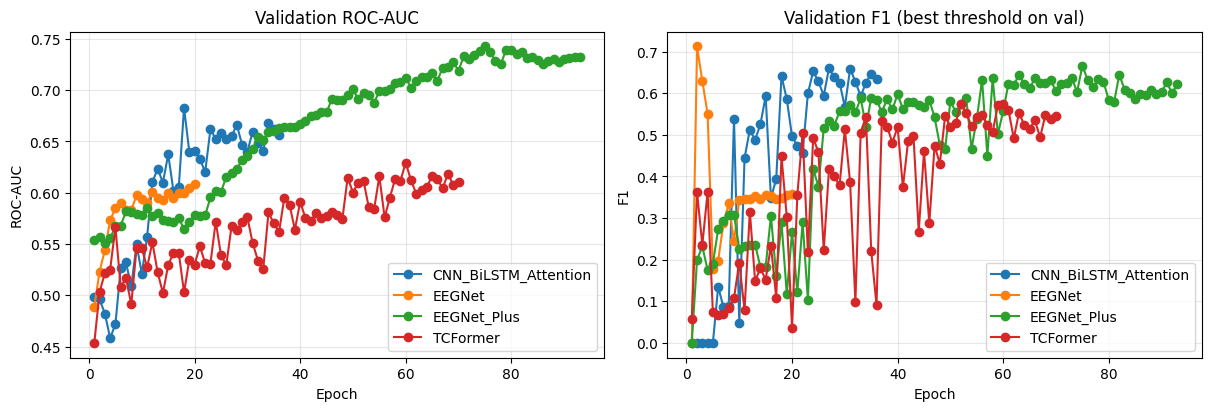

,model,best_threshold
1,EEGNet,0.52
2,EEGNet_Plus,0.58
3,TCFormer,0.65
0,CNN_BiLSTM_Attention,0.78


In [22]:

if deep_histories:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for model_name, history_df in deep_histories.items():
        axes[0].plot(history_df["epoch"], history_df["val_roc_auc"], marker="o", label=model_name)
        axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", label=model_name)

    axes[0].set_title("Validation ROC-AUC")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("ROC-AUC")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Validation F1 (best threshold on val)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.show()

    threshold_summary_df = pd.DataFrame([
        {
            "model": model_name,
            "best_threshold": deep_results[model_name].get("best_threshold", np.nan),
        }
        for model_name in deep_results
    ]).sort_values("best_threshold")

    display(threshold_summary_df)
else:
    print("Nessuna history deep disponibile: controlla eventuali errori di training nelle celle precedenti.")


### 13-bis) Ablation e analisi di calibrazione/threshold

Qui aggiungiamo tre letture utili da esame:

1. **ablation architetturale**: confronto tra famiglie di modelli deep;
2. **ablation del post-processing** sul miglior modello deep;
3. **diagnostica di calibrazione e Platt scaling** in un setup time-aware train/val/test.


,model,n_parameters,selected_gamma,best_threshold,precision,recall,f1,f0_5,balanced_accuracy,roc_auc,false_alarms_per_hour_window_level,latency_ms_per_sample
0,CNN_BiLSTM_Attention,28962,1.5,0.78,0.067961,0.486111,0.119250,0.082083,0.507761,0.504303,101274.725275,0.124744
1,EEGNet_Plus,22341,1.0,0.58,0.011062,0.069444,0.019084,0.013298,0.315605,0.349156,94312.087912,0.490415
2,EEGNet,2441,1.5,0.52,0.000000,0.000000,0.000000,0.000000,0.500000,0.536744,0.000000,0.118292
3,TCFormer,163796,2.0,0.65,0.000000,0.000000,0.000000,0.000000,0.335294,0.297985,70892.307692,0.455428


,model,variant,threshold,use_prob_smoothing,use_hysteresis,accuracy,balanced_accuracy,precision,recall,f1,...,roc_auc,tn,fp,fn,tp,false_alarms_per_hour_window_level,processed_prob_mean,threshold_low,postprocess_smoothing,postprocess_hysteresis
0,CNN_BiLSTM_Attention,raw_thr_0.50,0.50,False,False,0.229853,0.581291,0.077936,0.986111,0.144456,...,0.504303,180,840,1,71,177230.769231,0.703332,0.42,False,False
1,CNN_BiLSTM_Attention,raw_best_thr,0.78,False,False,0.516484,0.508824,0.068182,0.500000,0.120000,...,0.504303,528,492,36,36,103806.593407,0.703332,0.70,False,False
2,CNN_BiLSTM_Attention,best_thr_plus_smoothing_hyst,0.78,True,True,0.526557,0.507761,0.067961,0.486111,0.119250,...,0.504303,540,480,37,35,101274.725275,0.703630,0.70,True,True
3,CNN_BiLSTM_Attention,best_thr_plus_smoothing,0.78,True,False,0.591575,0.478023,0.058962,0.347222,0.100806,...,0.504303,621,399,47,25,84184.615385,0.703630,0.70,True,False


,family,variant,selected_threshold,brier,log_loss,ece,mean_pred,observed_rate,accuracy,balanced_accuracy,...,roc_auc,tn,fp,fn,tp,false_alarms_per_hour_window_level,processed_prob_mean,threshold_low,postprocess_smoothing,postprocess_hysteresis
0,Tabular_BestChrono,raw,0.90,0.306040,1.000595,0.384638,0.440432,0.081442,0.900312,0.542358,...,0.532882,2002,62,162,21,6357.276368,0.439902,0.82,True,True
1,Tabular_BestChrono,platt_scaled,0.55,0.124943,0.425615,0.210221,0.291663,0.081442,0.908767,0.494671,...,0.532882,2042,22,183,0,2255.807744,0.291519,0.47,True,True
2,Deep_CNN_BiLSTM_Attention,raw,0.78,0.505160,1.355971,0.637398,0.703332,0.065934,0.526557,0.507761,...,0.504303,540,480,37,35,101274.725275,0.703630,0.70,True,True
3,Deep_CNN_BiLSTM_Attention,platt_scaled,0.52,0.241578,0.668487,0.395010,0.460944,0.065934,0.547619,0.506127,...,0.504303,565,455,39,33,96000.000000,0.461284,0.44,True,True


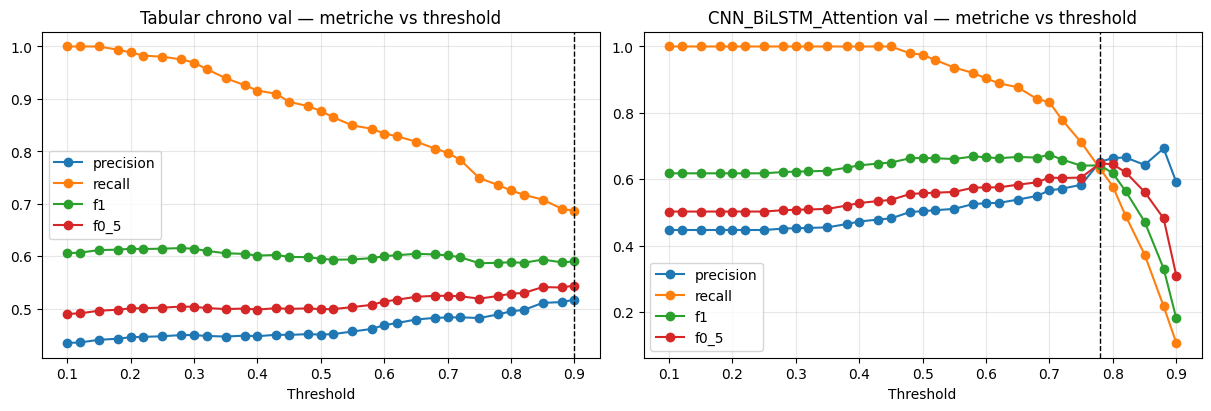

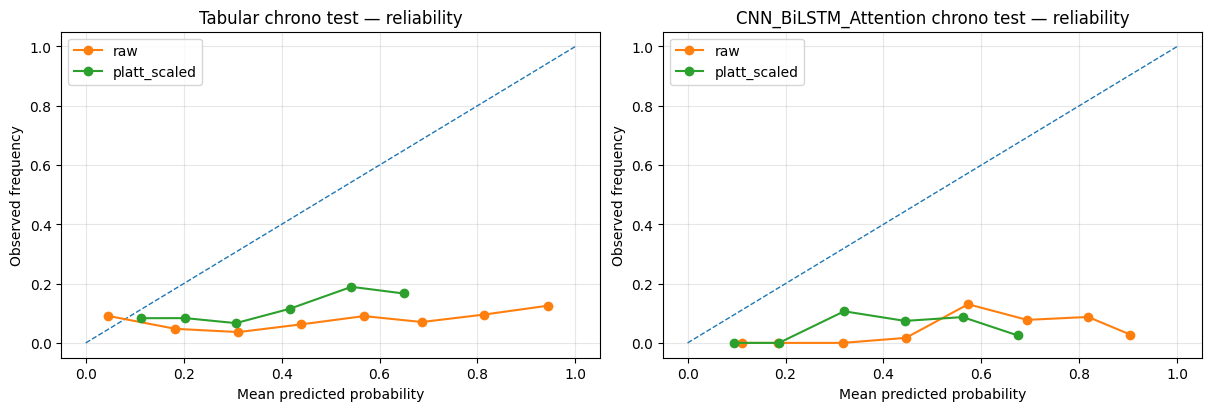

In [23]:

from sklearn.calibration import calibration_curve

def get_estimator_scores(estimator, X_input):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_input)[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_input)
        scores = np.asarray(scores, dtype=float)
        return 1.0 / (1.0 + np.exp(-scores))
    return estimator.predict(X_input).astype(float)

# ----------------------------
# 1) Architetture deep: ablation "macro"
# ----------------------------
deep_architecture_ablation_df = (
    deep_comparison_df[
        ["model", "n_parameters", "selected_gamma", "best_threshold", "precision", "recall", "f1", "f0_5", "balanced_accuracy", "roc_auc", "false_alarms_per_hour_window_level", "latency_ms_per_sample"]
    ]
    .sort_values(by=["f0_5", "precision", "f1"], ascending=False)
    .reset_index(drop=True)
)
display(deep_architecture_ablation_df)

# ----------------------------
# 2) Ablation del post-processing sul best deep
# ----------------------------
best_deep_name = deep_architecture_ablation_df.loc[0, "model"]
best_deep = deep_results[best_deep_name]
best_deep_thr = float(best_deep["best_threshold"])
best_deep_y_true = np.asarray(best_deep["test_y_true"]).astype(int)
best_deep_y_prob = np.asarray(best_deep["test_y_prob"], dtype=float)

postproc_variants = [
    {"variant": "raw_thr_0.50", "threshold": 0.50, "use_prob_smoothing": False, "use_hysteresis": False},
    {"variant": "raw_best_thr", "threshold": best_deep_thr, "use_prob_smoothing": False, "use_hysteresis": False},
    {"variant": "best_thr_plus_smoothing", "threshold": best_deep_thr, "use_prob_smoothing": True, "use_hysteresis": False},
    {"variant": "best_thr_plus_smoothing_hyst", "threshold": best_deep_thr, "use_prob_smoothing": True, "use_hysteresis": True},
]
postproc_rows = []
for cfg in postproc_variants:
    metrics = compute_classification_metrics(
        best_deep_y_true,
        best_deep_y_prob,
        threshold=cfg["threshold"],
        use_prob_smoothing=cfg["use_prob_smoothing"],
        use_hysteresis=cfg["use_hysteresis"],
        smoothing_alpha=PROB_SMOOTH_ALPHA,
        hysteresis_gap=HYSTERESIS_GAP,
    )
    postproc_rows.append({"model": best_deep_name, **cfg, **metrics})
postproc_ablation_df = pd.DataFrame(postproc_rows).sort_values(by=["f0_5", "precision", "f1"], ascending=False).reset_index(drop=True)
display(postproc_ablation_df)

# ----------------------------
# 3) Calibrazione + threshold analysis in split time-aware 70/15/15
# ----------------------------
chrono_tabular_estimator = clone(best_estimator)
chrono_tabular_estimator.fit(X_train_raw, y_train_raw)

tab_val_prob_raw = get_estimator_scores(chrono_tabular_estimator, X_val_raw)
tab_test_prob_raw = get_estimator_scores(chrono_tabular_estimator, X_test_raw_dl)
tab_thr_row_raw, tab_thr_table_raw = find_best_threshold(
    y_val_raw.to_numpy(),
    tab_val_prob_raw,
    thresholds=THRESHOLD_GRID,
    metric=THRESHOLD_METRIC,
    policy=THRESHOLD_POLICY,
    min_precision=MIN_PRECISION_CLOSED,
)
tab_test_metrics_raw = compute_classification_metrics(y_test_raw_dl.to_numpy(), tab_test_prob_raw, threshold=float(tab_thr_row_raw["threshold"]))

tab_platt = fit_platt_scaler_from_probs(y_val_raw.to_numpy(), tab_val_prob_raw)
tab_val_prob_cal = apply_platt_scaler_from_probs(tab_platt, tab_val_prob_raw)
tab_test_prob_cal = apply_platt_scaler_from_probs(tab_platt, tab_test_prob_raw)
tab_thr_row_cal, tab_thr_table_cal = find_best_threshold(
    y_val_raw.to_numpy(),
    tab_val_prob_cal,
    thresholds=THRESHOLD_GRID,
    metric=THRESHOLD_METRIC,
    policy=THRESHOLD_POLICY,
    min_precision=MIN_PRECISION_CLOSED,
)
tab_test_metrics_cal = compute_classification_metrics(y_test_raw_dl.to_numpy(), tab_test_prob_cal, threshold=float(tab_thr_row_cal["threshold"]))

deep_val_prob_raw = np.asarray(best_deep["val_y_prob"], dtype=float)
deep_test_prob_raw = np.asarray(best_deep["test_y_prob"], dtype=float)
deep_val_y_true = np.asarray(best_deep["val_y_true"]).astype(int)
deep_test_y_true = np.asarray(best_deep["test_y_true"]).astype(int)

deep_thr_row_raw, deep_thr_table_raw = find_best_threshold(
    deep_val_y_true,
    deep_val_prob_raw,
    thresholds=THRESHOLD_GRID,
    metric=THRESHOLD_METRIC,
    policy=THRESHOLD_POLICY,
    min_precision=MIN_PRECISION_CLOSED,
)
deep_test_metrics_raw = compute_classification_metrics(deep_test_y_true, deep_test_prob_raw, threshold=float(deep_thr_row_raw["threshold"]))

deep_platt = fit_platt_scaler_from_probs(deep_val_y_true, deep_val_prob_raw)
deep_val_prob_cal = apply_platt_scaler_from_probs(deep_platt, deep_val_prob_raw)
deep_test_prob_cal = apply_platt_scaler_from_probs(deep_platt, deep_test_prob_raw)
deep_thr_row_cal, deep_thr_table_cal = find_best_threshold(
    deep_val_y_true,
    deep_val_prob_cal,
    thresholds=THRESHOLD_GRID,
    metric=THRESHOLD_METRIC,
    policy=THRESHOLD_POLICY,
    min_precision=MIN_PRECISION_CLOSED,
)
deep_test_metrics_cal = compute_classification_metrics(deep_test_y_true, deep_test_prob_cal, threshold=float(deep_thr_row_cal["threshold"]))

calibration_rows = [
    {
        "family": "Tabular_BestChrono",
        "variant": "raw",
        "selected_threshold": float(tab_thr_row_raw["threshold"]),
        **summarize_probability_quality(y_test_raw_dl.to_numpy(), tab_test_prob_raw),
        **tab_test_metrics_raw,
    },
    {
        "family": "Tabular_BestChrono",
        "variant": "platt_scaled",
        "selected_threshold": float(tab_thr_row_cal["threshold"]),
        **summarize_probability_quality(y_test_raw_dl.to_numpy(), tab_test_prob_cal),
        **tab_test_metrics_cal,
    },
    {
        "family": f"Deep_{best_deep_name}",
        "variant": "raw",
        "selected_threshold": float(deep_thr_row_raw["threshold"]),
        **summarize_probability_quality(deep_test_y_true, deep_test_prob_raw),
        **deep_test_metrics_raw,
    },
    {
        "family": f"Deep_{best_deep_name}",
        "variant": "platt_scaled",
        "selected_threshold": float(deep_thr_row_cal["threshold"]),
        **summarize_probability_quality(deep_test_y_true, deep_test_prob_cal),
        **deep_test_metrics_cal,
    },
]
calibration_comparison_df = pd.DataFrame(calibration_rows)
display(calibration_comparison_df)

# Curve threshold su validation (best deep + best tabular chrono)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for col in ["precision", "recall", "f1", "f0_5"]:
    axes[0].plot(tab_thr_table_raw["threshold"], tab_thr_table_raw[col], marker="o", label=col)
axes[0].axvline(float(tab_thr_row_raw["threshold"]), color="black", linestyle="--", linewidth=1)
axes[0].set_title("Tabular chrono val — metriche vs threshold")
axes[0].set_xlabel("Threshold")
axes[0].grid(alpha=0.3)
axes[0].legend()

for col in ["precision", "recall", "f1", "f0_5"]:
    axes[1].plot(deep_thr_table_raw["threshold"], deep_thr_table_raw[col], marker="o", label=col)
axes[1].axvline(float(deep_thr_row_raw["threshold"]), color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"{best_deep_name} val — metriche vs threshold")
axes[1].set_xlabel("Threshold")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.show()

# Reliability / calibration curve sul test
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, y_true_curve, curves, title in [
    (
        axes[0],
        y_test_raw_dl.to_numpy(),
        [("raw", tab_test_prob_raw), ("platt_scaled", tab_test_prob_cal)],
        "Tabular chrono test — reliability"
    ),
    (
        axes[1],
        deep_test_y_true,
        [("raw", deep_test_prob_raw), ("platt_scaled", deep_test_prob_cal)],
        f"{best_deep_name} chrono test — reliability"
    ),
]:
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    for label, probs_curve in curves:
        frac_pos, mean_pred = calibration_curve(y_true_curve, probs_curve, n_bins=8, strategy="uniform")
        ax.plot(mean_pred, frac_pos, marker="o", label=label)
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()


### Come leggere il ramo deep

- Se la **CNN + BiLSTM + Attention** batte EEGNet, EEGNet+ e TCFormer sul test cronologico, allora la componente ricorrente + attention sta catturando struttura sequenziale utile.
- Se la **TCFormer** emerge come migliore, allora la combinazione **convolution + global attention + TCN head** sta gestendo bene il trade-off tra pattern locali e dipendenze più lunghe.
- Se **EEGNet** o **EEGNet+** ottengono metriche simili ma con molti meno parametri e minore latenza, allora restano la scelta migliore da difendere per **real-time / deployment leggero**.
- Se il miglioramento arriva soprattutto da **mixup + TTA + threshold tuning**, allora il problema dominante non era tanto l'architettura quanto la robustezza della decision rule sotto forte imbalance.
- Se il **gamma sweep** seleziona valori molto diversi tra modelli, allora il comportamento della focal loss dipende davvero dalla famiglia architetturale e non va fissato una volta per tutte.
- Se tutti i modelli restano deboli sull'ultimo blocco temporale, il problema dominante non è l'architettura ma il **forte shift di distribuzione nel tempo** già emerso nel controllo cronologico tabellare.


## 13) Salvataggio artefatti

In [24]:
import joblib
from datetime import datetime

output_dir = Path("artifacts_eeg_eye_state")
output_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_estimator, output_dir / "best_model_random_split.joblib")
comparison_df.to_csv(output_dir / "model_comparison.csv", index=False)
robustness_df.to_csv(output_dir / "robustness_check.csv", index=False)
perm_df.to_csv(output_dir / "permutation_importance.csv", index=False)


if "blocked_chrono_cv_df" in globals():
    blocked_chrono_cv_df.to_csv(output_dir / "blocked_chrono_cv.csv", index=False)
if "blocked_chrono_summary_df" in globals():
    blocked_chrono_summary_df.to_csv(output_dir / "blocked_chrono_summary.csv", index=False)
if "deep_architecture_ablation_df" in globals():
    deep_architecture_ablation_df.to_csv(output_dir / "deep_architecture_ablation.csv", index=False)
if "postproc_ablation_df" in globals():
    postproc_ablation_df.to_csv(output_dir / "best_deep_postproc_ablation.csv", index=False)
if "calibration_comparison_df" in globals():
    calibration_comparison_df.to_csv(output_dir / "calibration_comparison.csv", index=False)

metrics_payload = {
    "timestamp": datetime.now().isoformat(),
    "random_state": RANDOM_STATE,
    "best_model_name": best_model_name,
    "best_params": {k: str(v) for k, v in search_results[best_model_name]["best_params"].items()},
    "best_cv_roc_auc": float(search_results[best_model_name]["cv_best_roc_auc"]),
    "test_metrics_random_split": {k: float(v) for k, v in random_metrics.items()},
    "test_metrics_chronological_holdout": {k: float(v) for k, v in time_metrics.items()},
    "all_models_random_split": [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in comparison_df.to_dict(orient="records")
    ],
}

if "deep_comparison_df" in globals():
    deep_comparison_df.to_csv(output_dir / "deep_model_comparison.csv", index=False)
    metrics_payload["deep_models"] = [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in deep_comparison_df.to_dict(orient="records")
    ]
    if "deep_pretrain_df" in globals():
        deep_pretrain_df.to_csv(output_dir / "deep_pretrain_log.csv", index=False)
    if "quantization_summary_df" in globals() and len(quantization_summary_df) > 0:
        quantization_summary_df.to_csv(output_dir / "quantization_summary.csv", index=False)
        metrics_payload["quantization"] = [
            {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
            for row in quantization_summary_df.to_dict(orient="records")
        ]
    for model_name, result in deep_results.items():
        torch.save(result["model"].state_dict(), output_dir / f"{model_name}.pt")
        result["history"].to_csv(output_dir / f"{model_name}_history.csv", index=False)
        if result.get("threshold_table") is not None:
            result["threshold_table"].to_csv(output_dir / f"{model_name}_thresholds.csv", index=False)
        if result.get("gamma_sweep_table") is not None:
            result["gamma_sweep_table"].to_csv(output_dir / f"{model_name}_gamma_sweep.csv", index=False)


if "blocked_chrono_summary_df" in globals():
    metrics_payload["blocked_chrono_cv_summary"] = [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in blocked_chrono_summary_df.to_dict(orient="records")
    ]
if "deep_architecture_ablation_df" in globals():
    metrics_payload["deep_architecture_ablation"] = [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in deep_architecture_ablation_df.to_dict(orient="records")
    ]
if "postproc_ablation_df" in globals():
    metrics_payload["best_deep_postproc_ablation"] = [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in postproc_ablation_df.to_dict(orient="records")
    ]
if "calibration_comparison_df" in globals():
    metrics_payload["calibration_comparison"] = [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in row.items()}
        for row in calibration_comparison_df.to_dict(orient="records")
    ]


with open(output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print("Artefatti salvati in:", output_dir.resolve())
print("- best_model_random_split.joblib")
print("- model_comparison.csv")
print("- robustness_check.csv")
print("- permutation_importance.csv")
print("- metrics.json")
if "blocked_chrono_cv_df" in globals():
    print("- blocked_chrono_cv.csv")
    print("- blocked_chrono_summary.csv")
if "deep_architecture_ablation_df" in globals():
    print("- deep_architecture_ablation.csv")
if "postproc_ablation_df" in globals():
    print("- best_deep_postproc_ablation.csv")
if "calibration_comparison_df" in globals():
    print("- calibration_comparison.csv")
if "deep_comparison_df" in globals():
    print("- deep_model_comparison.csv")
    if "deep_pretrain_df" in globals():
        print("- deep_pretrain_log.csv")
    if "quantization_summary_df" in globals() and len(quantization_summary_df) > 0:
        print("- quantization_summary.csv")
    for model_name in deep_results:
        print(f"- {model_name}.pt")
        print(f"- {model_name}_history.csv")
        if deep_results[model_name].get("threshold_table") is not None:
            print(f"- {model_name}_thresholds.csv")
        if deep_results[model_name].get("gamma_sweep_table") is not None:
            print(f"- {model_name}_gamma_sweep.csv")


Artefatti salvati in: C:\Users\11625216\Desktop\artifacts_eeg_eye_state
- best_model_random_split.joblib
- model_comparison.csv
- robustness_check.csv
- permutation_importance.csv
- metrics.json
- blocked_chrono_cv.csv
- blocked_chrono_summary.csv
- deep_architecture_ablation.csv
- best_deep_postproc_ablation.csv
- calibration_comparison.csv
- deep_model_comparison.csv
- deep_pretrain_log.csv
- quantization_summary.csv
- CNN_BiLSTM_Attention.pt
- CNN_BiLSTM_Attention_history.csv
- CNN_BiLSTM_Attention_thresholds.csv
- CNN_BiLSTM_Attention_gamma_sweep.csv
- EEGNet.pt
- EEGNet_history.csv
- EEGNet_thresholds.csv
- EEGNet_gamma_sweep.csv
- EEGNet_Plus.pt
- EEGNet_Plus_history.csv
- EEGNet_Plus_thresholds.csv
- EEGNet_Plus_gamma_sweep.csv
- TCFormer.pt
- TCFormer_history.csv
- TCFormer_thresholds.csv
- TCFormer_gamma_sweep.csv


## 15) Conclusione

Questa versione:
- mantiene il flusso end-to-end corretto del notebook migliore;
- migliora l'EDA con alcuni elementi davvero utili del secondo;
- evita passaggi ad alto rischio di leakage;
- aggiunge un controllo temporale separato, che è il modo più pulito per affrontare la natura sequenziale del dataset;
- introduce un **ramo deep time-aware** con:
  - una **CNN + BiLSTM + Attention** più espressiva;
  - una **EEGNet classica** più leggera e più difendibile per scenari real-time;
  - una **EEGNet+ migliorata** come via intermedia compatta ma più capace;
  - una **TCFormer compatta potenziata** che combina conv multi-scala, mixing spaziale, Transformer encoder e head temporale;
- rafforza il training deep con:
  - **Focal Loss + `pos_weight` train-only**;
  - **piccolo sweep di `gamma`** invece di fissarlo alla cieca;
  - **windowing corto** (`32`);
  - **più epoche** (`100`) e scheduler più paziente;
  - **augmentation più ricca** (noise, gain jitter, time shift, time masking, mixup);
  - **TTA** leggera su validation/test;
  - **threshold tuning su validation con floor di precisione più severo (0.70)** orientato a ridurre i falsi allarmi.

La lettura metodologicamente più importante resta questa:
- lo **split casuale** misura uno scenario favorevole;
- il **test cronologico** misura uno scenario più duro ma più realistico;
- se i modelli deep migliorano solo di poco sul chrono test, il collo di bottiglia principale è lo **shift di distribuzione nel tempo**, non la sola architettura.

Questa configurazione è più forte del notebook precedente perché applica quasi tutti i miglioramenti pratici richiesti **senza introdurre ensemble** e senza rompere il principio fondamentale del notebook: niente leakage dal futuro e scelta della soglia fatta solo sulla validation.


## Hidden Markov Model (HMM) Analysis with Windowing

This section implements HMM-based analysis on the EEG/Eye dataset using a sliding window approach. The model is evaluated using standard classification metrics.

In [18]:
!pip install hmmlearn

# HMM Analysis with Sliding Window
import numpy as np
from hmmlearn import hmm
from sklearn.metrics import classification_report, accuracy_score

# Parameters for windowing
window_size = 50  # number of samples per window
step_size = 25    # overlap between windows

# Prepare data for HMM (using X_train, y_train, X_test, y_test)
def create_windows(X, y, window_size, step_size):
    X_windows, y_windows = [], []
    for start in range(0, len(X) - window_size + 1, step_size):
        end = start + window_size
        X_windows.append(X.iloc[start:end].values)
        # Majority label in the window
        y_windows.append(y.iloc[start:end].mode()[0])
    return np.array(X_windows), np.array(y_windows)

X_train_win, y_train_win = create_windows(X_train, y_train, window_size, step_size)
X_test_win, y_test_win = create_windows(X_test, y_test, window_size, step_size)

# Flatten windows for HMM (HMM expects 2D array)
X_train_flat = X_train_win.reshape(-1, X_train_win.shape[-1])
X_test_flat = X_test_win.reshape(-1, X_test_win.shape[-1])

# Fit HMM (GaussianHMM)
n_states = len(np.unique(y_train))
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=100, random_state=RANDOM_STATE)
hmm_model.fit(X_train_flat)

# Predict hidden states for test windows
hidden_states = hmm_model.predict(X_test_flat)

# Map hidden states to actual labels using majority voting in each window
from scipy.stats import mode
window_preds = []
for i in range(0, len(hidden_states), window_size):
    window = hidden_states[i:i+window_size]
    # Assign the most frequent state in the window
    window_preds.append(mode(window)[0][0])
window_preds = np.array(window_preds)

# Evaluate
print('HMM Classification Report:')
print(classification_report(y_test_win, window_preds))
print('HMM Accuracy:', accuracy_score(y_test_win, window_preds))


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


IndexError: invalid index to scalar variable.

In [ ]:
# Install hmmlearn if not already installed
!pip install hmmlearn

# HMM Analysis with Sliding Window
import numpy as np
from hmmlearn import hmm
from sklearn.metrics import classification_report, accuracy_score

# Parameters for windowing
window_size = 50  # number of samples per window
step_size = 25    # overlap between windows

# Prepare data for HMM (using X_train, y_train, X_test, y_test)
def create_windows(X, y, window_size, step_size):
    X_windows, y_windows = [], []
    for start in range(0, len(X) - window_size + 1, step_size):
        end = start + window_size
        X_windows.append(X.iloc[start:end].values)
        # Majority label in the window
        y_windows.append(y.iloc[start:end].mode()[0])
    return np.array(X_windows), np.array(y_windows)

X_train_win, y_train_win = create_windows(X_train, y_train, window_size, step_size)
X_test_win, y_test_win = create_windows(X_test, y_test, window_size, step_size)

# Flatten windows for HMM (HMM expects 2D array)
X_train_flat = X_train_win.reshape(-1, X_train_win.shape[-1])
X_test_flat = X_test_win.reshape(-1, X_test_win.shape[-1])

# Fit HMM (GaussianHMM)
n_states = len(np.unique(y_train))
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=100, random_state=RANDOM_STATE)
hmm_model.fit(X_train_flat)

# Predict hidden states for test windows
hidden_states = hmm_model.predict(X_test_flat)

# Map hidden states to actual labels using majority voting in each window
from scipy.stats import mode
window_preds = []
for i in range(0, len(hidden_states), window_size):
    window = hidden_states[i:i+window_size]
    # Assign the most frequent state in the window
    window_preds.append(mode(window, keepdims=True).mode[0])
window_preds = np.array(window_preds)

# Evaluate
print('HMM Classification Report:')
print(classification_report(y_test_win, window_preds))
print('HMM Accuracy:', accuracy_score(y_test_win, window_preds))


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


IndexError: invalid index to scalar variable.